# Task K — AUG Rolling Walk-Forward Optimization

Task K applies the finalized rolling walk-forward framework from Task 5 to
**AUG / SHFE Gold Futures**.

The objective is to evaluate whether the same Channel WithDDControl strategy
retains meaningful out-of-sample performance when transferred from Soybean to
a different futures market.

The baseline walk-forward design uses:

- 4-year in-sample optimization windows
- 3-month non-overlapping out-of-sample deployment periods
- the same strategy logic as the finalized Soybean analysis
- the full prescribed parameter grid
- optimization objective: Net Profit / |Maximum Drawdown|
- IS-conditioned OOS evaluation

All AUG profit and loss is reported in CNY.

Task K therefore serves as a cross-market robustness test rather than a search
for a new strategy design.

## 0. Imports and Configuration

This section defines the finalized AUG data source, contract assumptions,
walk-forward design, and exact optimization grid.

All strategy settings are aligned with the finalized Soybean framework so that
the Gold results can be interpreted as a clean cross-market robustness test.

In [1]:
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import (
    njit,
    prange,
    get_num_threads
)


warnings.filterwarnings(
    "ignore"
)


# ============================================================
# DATA
# ============================================================

CLEAN = (
    Path("data")
    /
    "clean"
)

AUG_PATH = (
    CLEAN
    /
    "AUG.parquet"
)


# ============================================================
# AUG / SHFE GOLD CONTRACT SETTINGS
# ============================================================

PV = 1000.0

SLPG = 0.065

INITIAL_EQUITY = (
    100_000.0
)

CURRENCY = "CNY"


# ============================================================
# WALK-FORWARD DESIGN
# ============================================================

IS_YEARS = 4

OOS_MONTHS = 3


# ============================================================
# EXACT PARAMETER GRID
# ============================================================

CHNLEN_RANGE = np.arange(
    500,
    10001,
    10
)


STPPCT_RANGE = np.round(
    np.arange(
        0.005,
        0.101,
        0.001
    ),
    3
)


N_COMBINATIONS = (
    len(CHNLEN_RANGE)
    *
    len(STPPCT_RANGE)
)


# ============================================================
# CONFIGURATION SUMMARY
# ============================================================

config_table = pd.DataFrame(
    {
        "Setting": [
            "Market",
            "Currency",
            "Point Value",
            "Round-Turn Slippage",
            "Initial Equity",
            "IS Window",
            "OOS Horizon",
            "ChnLen Grid",
            "StpPct Grid",
            "Combinations per Window"
        ],

        "Value": [
            "AUG / SHFE Gold Futures",
            CURRENCY,
            PV,
            SLPG,
            INITIAL_EQUITY,
            f"{IS_YEARS} years",
            f"{OOS_MONTHS} months",
            (
                f"500 to 10000 "
                f"(step 10; {len(CHNLEN_RANGE)} values)"
            ),
            (
                f"0.005 to 0.100 "
                f"(step 0.001; {len(STPPCT_RANGE)} values)"
            ),
            f"{N_COMBINATIONS:,}"
        ]
    }
)


print(
    "TASK K — AUG WALK-FORWARD CONFIGURATION"
)

print(
    "=" * 76
)

display(
    config_table
)


print(
    f"\nNumba threads available: "
    f"{get_num_threads()}"
)

TASK K — AUG WALK-FORWARD CONFIGURATION


,Setting,Value
0,Market,AUG / SHFE Gold Futures
1,Currency,CNY
2,Point Value,1000.0
3,Round-Turn Slippage,0.065
4,Initial Equity,100000.0
5,IS Window,4 years
6,OOS Horizon,3 months
7,ChnLen Grid,500 to 10000 (step 10; 951 values)
8,StpPct Grid,0.005 to 0.100 (step 0.001; 96 values)
9,Combinations per Window,"91,296"



Numba threads available: 8


## 1. Load and Validate Finalized AUG Data

Task K uses the finalized clean AUG dataset produced by the common data-cleaning
pipeline rather than reprocessing the raw CSV inside the strategy notebook.

This ensures that the Gold walk-forward analysis uses the same validated data
source as the rest of the project.

Before optimization, the dataset is checked for chronological ordering,
duplicate timestamps, missing OHLC values, and basic OHLC consistency.

In [2]:
aug = pd.read_parquet(
    AUG_PATH
).copy()


# ------------------------------------------------------------
# Standardize timestamp representation
# ------------------------------------------------------------

if "ts" in aug.columns:

    aug["ts"] = pd.to_datetime(
        aug["ts"]
    )

    aug = (
        aug
        .sort_values("ts")
        .reset_index(drop=True)
    )

    ts_pd = pd.DatetimeIndex(
        aug["ts"]
    )

else:

    aug.index = pd.to_datetime(
        aug.index
    )

    aug = (
        aug
        .sort_index()
    )

    ts_pd = pd.DatetimeIndex(
        aug.index
    )


# ------------------------------------------------------------
# Extract arrays used by the strategy engine
# ------------------------------------------------------------

Open = aug["Open"].to_numpy(
    dtype=np.float64
)

High = aug["High"].to_numpy(
    dtype=np.float64
)

Low = aug["Low"].to_numpy(
    dtype=np.float64
)

Close = aug["Close"].to_numpy(
    dtype=np.float64
)

N = len(aug)


# ------------------------------------------------------------
# Data-quality checks
# ------------------------------------------------------------

duplicate_timestamps = int(
    ts_pd.duplicated().sum()
)

missing_ohlc = int(
    aug[
        ["Open", "High", "Low", "Close"]
    ]
    .isna()
    .sum()
    .sum()
)

chronological = bool(
    ts_pd.is_monotonic_increasing
)

ohlc_consistent = bool(
    (
        High
        >=
        np.maximum(Open, Close)
    ).all()
    and
    (
        Low
        <=
        np.minimum(Open, Close)
    ).all()
    and
    (
        High >= Low
    ).all()
)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

data_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Start",
            "End",
            "Duplicate timestamps",
            "Missing OHLC values",
            "Chronological",
            "OHLC consistent"
        ],

        "Value": [
            f"{N:,}",
            str(ts_pd[0]),
            str(ts_pd[-1]),
            duplicate_timestamps,
            missing_ohlc,
            chronological,
            ohlc_consistent
        ]
    }
)


print(
    "FINALIZED AUG DATA"
)

print(
    "=" * 76
)

display(
    data_summary
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert N > 0

assert chronological

assert duplicate_timestamps == 0

assert missing_ohlc == 0

assert ohlc_consistent


print(
    "\nAll AUG data validation checks passed."
)

FINALIZED AUG DATA


,Metric,Value
0,Rows,"138,744"
1,Start,2018-05-03 09:05:00
2,End,2026-04-10 15:00:00
3,Duplicate timestamps,0
4,Missing OHLC values,0
5,Chronological,True
6,OHLC consistent,True



All AUG data validation checks passed.


## 2. Exact Strategy and Optimization Engine

The AUG analysis uses the same finalized Channel WithDDControl implementation
as the Soybean walk-forward analysis.

The strategy logic is unchanged across markets. Only the AUG contract
specifications and price data differ.

For each channel length, the upper and lower breakout channels are constructed
strictly from prior bars, excluding the current bar. The strategy then applies
the same entry, reversal, trailing-stop, slippage, and mark-to-market accounting
rules as the finalized Task 5 engine.

A monotonic-deque implementation is used to construct rolling channels in
linear time, while the stop-percentage dimension is evaluated in parallel.

In [3]:
# ------------------------------------------------------------
# 2.1 O(N) prior-bar rolling channels
# ------------------------------------------------------------

@njit(cache=True)
def build_channels_deque(
    high,
    low,
    length
):

    n = len(high)

    hh = np.empty(
        n,
        dtype=np.float64
    )

    ll = np.empty(
        n,
        dtype=np.float64
    )

    hh[:] = np.inf
    ll[:] = -np.inf


    max_deque = np.empty(
        n,
        dtype=np.int64
    )

    min_deque = np.empty(
        n,
        dtype=np.int64
    )


    max_head = 0
    max_tail = 0

    min_head = 0
    min_tail = 0


    for k in range(n):

        # ----------------------------------------------------
        # Remove observations that are no longer inside
        # [k-length, k-1].
        # ----------------------------------------------------

        lower_bound = (
            k - length
        )


        while (
            max_head < max_tail
            and
            max_deque[max_head] < lower_bound
        ):
            max_head += 1


        while (
            min_head < min_tail
            and
            min_deque[min_head] < lower_bound
        ):
            min_head += 1


        # ----------------------------------------------------
        # Channel for bar k uses PRIOR bars only.
        # ----------------------------------------------------

        if k >= length:

            hh[k] = high[
                max_deque[max_head]
            ]

            ll[k] = low[
                min_deque[min_head]
            ]


        # ----------------------------------------------------
        # Add current bar AFTER computing the channel.
        # Therefore current bar is excluded from HH[k]/LL[k].
        # ----------------------------------------------------

        while (
            max_head < max_tail
            and
            high[max_deque[max_tail - 1]]
            <=
            high[k]
        ):
            max_tail -= 1


        max_deque[max_tail] = k
        max_tail += 1


        while (
            min_head < min_tail
            and
            low[min_deque[min_tail - 1]]
            >=
            low[k]
        ):
            min_tail -= 1


        min_deque[min_tail] = k
        min_tail += 1


    return hh, ll


# ------------------------------------------------------------
# 2.2 Exact strategy scorer
# ------------------------------------------------------------

@njit(cache=True)
def score_strategy_fast(
    high,
    low,
    close,
    hh,
    ll,
    length,
    stop_pct,
    slpg,
    pv,
    initial_equity
):

    n = len(close)

    equity = initial_equity
    equity_max = initial_equity

    min_dd = 0.0

    position = 0

    benchmark_long = 0.0
    benchmark_short = 0.0


    for k in range(
        length,
        n
    ):

        traded = False

        delta = (
            pv
            *
            (close[k] - close[k - 1])
            *
            position
        )


        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy = (
                high[k] >= hh[k]
            )

            sell = (
                low[k] <= ll[k]
            )


            if buy and sell:

                delta = (
                    -slpg
                    +
                    pv
                    *
                    (ll[k] - hh[k])
                )


            elif buy:

                delta = (
                    -slpg / 2.0
                    +
                    pv
                    *
                    (close[k] - hh[k])
                )

                position = 1
                traded = True

                benchmark_long = high[k]


            elif sell:

                delta = (
                    -slpg / 2.0
                    -
                    pv
                    *
                    (close[k] - ll[k])
                )

                position = -1
                traded = True

                benchmark_short = low[k]


        # ====================================================
        # LONG
        # ====================================================

        if (
            position == 1
            and
            not traded
        ):

            sell_short = (
                low[k] <= ll[k]
            )

            sell = (
                low[k]
                <=
                benchmark_long
                *
                (1.0 - stop_pct)
            )


            if (
                sell_short
                and
                sell
            ):

                delta = (
                    delta
                    -
                    slpg
                    -
                    2.0
                    *
                    pv
                    *
                    (close[k] - ll[k])
                )

                position = -1

                benchmark_short = low[k]


            else:

                if sell:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        -
                        pv
                        *
                        (
                            close[k]
                            -
                            benchmark_long
                            *
                            (1.0 - stop_pct)
                        )
                    )

                    position = 0


                if sell_short:

                    delta = (
                        delta
                        -
                        slpg
                        -
                        2.0
                        *
                        pv
                        *
                        (close[k] - ll[k])
                    )

                    position = -1

                    benchmark_short = low[k]


            if high[k] > benchmark_long:

                benchmark_long = high[k]


        # ====================================================
        # SHORT
        # ====================================================

        if (
            position == -1
            and
            not traded
        ):

            buy_long = (
                high[k] >= hh[k]
            )

            buy = (
                high[k]
                >=
                benchmark_short
                *
                (1.0 + stop_pct)
            )


            if (
                buy_long
                and
                buy
            ):

                delta = (
                    delta
                    -
                    slpg
                    +
                    2.0
                    *
                    pv
                    *
                    (close[k] - hh[k])
                )

                position = 1

                benchmark_long = high[k]


            else:

                if buy:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        +
                        pv
                        *
                        (
                            close[k]
                            -
                            benchmark_short
                            *
                            (1.0 + stop_pct)
                        )
                    )

                    position = 0


                if buy_long:

                    delta = (
                        delta
                        -
                        slpg
                        +
                        2.0
                        *
                        pv
                        *
                        (close[k] - hh[k])
                    )

                    position = 1

                    benchmark_long = high[k]


            if low[k] < benchmark_short:

                benchmark_short = low[k]


        # ====================================================
        # EQUITY / DRAWDOWN
        # ====================================================

        equity += delta


        if equity > equity_max:

            equity_max = equity


        dd = (
            equity
            -
            equity_max
        )


        if dd < min_dd:

            min_dd = dd


    net_profit = (
        equity
        -
        initial_equity
    )


    if min_dd < 0.0:

        objective = (
            net_profit
            /
            abs(min_dd)
        )

    elif net_profit > 0.0:

        objective = net_profit

    else:

        objective = -np.inf


    return (
        net_profit,
        min_dd,
        objective
    )


# ------------------------------------------------------------
# 2.3 Parallel evaluation of the StpPct dimension
# ------------------------------------------------------------

@njit(
    parallel=True,
    cache=True
)
def score_stop_grid_parallel(
    high,
    low,
    close,
    hh,
    ll,
    length,
    stop_grid,
    slpg,
    pv,
    initial_equity
):

    m = len(stop_grid)

    profits = np.empty(
        m,
        dtype=np.float64
    )

    drawdowns = np.empty(
        m,
        dtype=np.float64
    )

    objectives = np.empty(
        m,
        dtype=np.float64
    )


    for j in prange(m):

        (
            profit,
            drawdown,
            objective
        ) = score_strategy_fast(
            high,
            low,
            close,
            hh,
            ll,
            length,
            stop_grid[j],
            slpg,
            pv,
            initial_equity
        )


        profits[j] = profit

        drawdowns[j] = drawdown

        objectives[j] = objective


    return (
        profits,
        drawdowns,
        objectives
    )


print(
    "Exact AUG strategy engine defined successfully."
)

print(
    f"Channel lengths : {len(CHNLEN_RANGE):,}"
)

print(
    f"Stop percentages: {len(STPPCT_RANGE):,}"
)

print(
    f"Full grid       : {N_COMBINATIONS:,} combinations"
)

Exact AUG strategy engine defined successfully.
Channel lengths : 951
Stop percentages: 96
Full grid       : 91,296 combinations


### 2.4 Validate Prior-Bar Channel Construction

Before using the optimized channel builder in the full parameter search, its
output is compared against a direct pandas rolling implementation.

The two implementations must agree numerically after the warm-up period. This
test verifies both the rolling-window boundaries and the exclusion of the
current bar from the breakout channel.

In [4]:
TEST_CHNLEN = 2000


# ------------------------------------------------------------
# Fast monotonic-deque implementation
# ------------------------------------------------------------

hh_fast, ll_fast = build_channels_deque(
    High,
    Low,
    TEST_CHNLEN
)


# ------------------------------------------------------------
# Direct pandas reference implementation
# ------------------------------------------------------------

hh_reference = (
    pd.Series(High)
    .rolling(
        TEST_CHNLEN,
        min_periods=TEST_CHNLEN
    )
    .max()
    .shift(1)
    .to_numpy()
)


ll_reference = (
    pd.Series(Low)
    .rolling(
        TEST_CHNLEN,
        min_periods=TEST_CHNLEN
    )
    .min()
    .shift(1)
    .to_numpy()
)


# ------------------------------------------------------------
# Compare only the valid post-warm-up region
# ------------------------------------------------------------

valid = np.arange(N) >= TEST_CHNLEN


hh_abs_error = np.max(
    np.abs(
        hh_fast[valid]
        -
        hh_reference[valid]
    )
)


ll_abs_error = np.max(
    np.abs(
        ll_fast[valid]
        -
        ll_reference[valid]
    )
)


hh_match = np.allclose(
    hh_fast[valid],
    hh_reference[valid],
    rtol=0.0,
    atol=0.0
)


ll_match = np.allclose(
    ll_fast[valid],
    ll_reference[valid],
    rtol=0.0,
    atol=0.0
)


# ------------------------------------------------------------
# Additional prior-bar boundary check
# ------------------------------------------------------------

first_valid_bar = TEST_CHNLEN

expected_first_hh = np.max(
    High[
        0:TEST_CHNLEN
    ]
)

expected_first_ll = np.min(
    Low[
        0:TEST_CHNLEN
    ]
)


first_hh_match = bool(
    hh_fast[first_valid_bar]
    ==
    expected_first_hh
)

first_ll_match = bool(
    ll_fast[first_valid_bar]
    ==
    expected_first_ll
)


# ------------------------------------------------------------
# Validation summary
# ------------------------------------------------------------

channel_validation = pd.DataFrame(
    {
        "Check": [
            "HH: deque = pandas rolling",
            "LL: deque = pandas rolling",
            "HH maximum absolute error",
            "LL maximum absolute error",
            "First HH uses prior bars only",
            "First LL uses prior bars only"
        ],

        "Result": [
            hh_match,
            ll_match,
            hh_abs_error,
            ll_abs_error,
            first_hh_match,
            first_ll_match
        ]
    }
)


print(
    "CHANNEL CONSTRUCTION VALIDATION"
)

print(
    "=" * 76
)

display(
    channel_validation
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert hh_match

assert ll_match

assert first_hh_match

assert first_ll_match


print(
    "\nExact prior-bar channel construction validated."
)

CHANNEL CONSTRUCTION VALIDATION


,Check,Result
0,HH: deque = pandas rolling,True
1,LL: deque = pandas rolling,True
2,HH maximum absolute error,0.0
3,LL maximum absolute error,0.0
4,First HH uses prior bars only,True
5,First LL uses prior bars only,True



Exact prior-bar channel construction validated.


### 2.5 Exact Full-Grid Optimizer

For each in-sample window, the optimizer evaluates the complete prescribed
parameter grid of 951 channel lengths and 96 stop percentages, for a total of
91,296 parameter combinations.

For each channel length, prior-bar channels are constructed once using the
validated monotonic-deque implementation. All stop-percentage candidates are
then evaluated in parallel.

The selected parameter pair is the combination that maximizes:

**Net Profit / |Maximum Drawdown|**

No coarse search, local refinement, or parameter pre-screening is used.

In [5]:
def optimize_full_grid_final(
    high,
    low,
    close,
    chnlen_grid,
    stop_grid,
    slpg,
    pv,
    initial_equity,
    show_progress=True
):

    best_objective = -np.inf

    best_length = None
    best_stop = None

    best_profit = None
    best_drawdown = None


    start_time = time.perf_counter()


    iterator = chnlen_grid

    if show_progress:

        try:
            from tqdm.auto import tqdm

            iterator = tqdm(
                chnlen_grid,
                desc="Full-grid optimization"
            )

        except ImportError:

            pass


    for length in iterator:

        length = int(length)


        # ----------------------------------------------------
        # Construct prior-bar channels once for this ChnLen
        # ----------------------------------------------------

        hh, ll = build_channels_deque(
            high,
            low,
            length
        )


        # ----------------------------------------------------
        # Evaluate all StpPct values in parallel
        # ----------------------------------------------------

        (
            profits,
            drawdowns,
            objectives
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            length,
            stop_grid,
            slpg,
            pv,
            initial_equity
        )


        # ----------------------------------------------------
        # Best stop percentage for this channel length
        # ----------------------------------------------------

        local_idx = int(
            np.argmax(objectives)
        )

        local_objective = float(
            objectives[local_idx]
        )


        # ----------------------------------------------------
        # Update global optimum
        # ----------------------------------------------------

        if local_objective > best_objective:

            best_objective = (
                local_objective
            )

            best_length = (
                length
            )

            best_stop = float(
                stop_grid[local_idx]
            )

            best_profit = float(
                profits[local_idx]
            )

            best_drawdown = float(
                drawdowns[local_idx]
            )


    elapsed = (
        time.perf_counter()
        -
        start_time
    )


    return {
        "ChnLen": best_length,
        "StpPct": best_stop,
        "NetProfit": best_profit,
        "MaxDrawdown": best_drawdown,
        "Objective": best_objective,
        "RuntimeSeconds": elapsed,
        "Evaluations": (
            len(chnlen_grid)
            *
            len(stop_grid)
        )
    }


print(
    "Exact full-grid optimizer defined successfully."
)

print(
    f"Search space: "
    f"{len(CHNLEN_RANGE):,} × "
    f"{len(STPPCT_RANGE):,} "
    f"= {N_COMBINATIONS:,} combinations per IS window."
)

Exact full-grid optimizer defined successfully.
Search space: 951 × 96 = 91,296 combinations per IS window.


## 3. Walk-Forward Calendar

The AUG walk-forward calendar follows the same baseline design as Task 5:

- 4 years of in-sample data
- 3 months of subsequent out-of-sample deployment
- non-overlapping quarterly OOS windows

Calendar boundaries are defined using calendar dates rather than fixed numbers
of bars. Each window uses all available AUG observations satisfying the
corresponding date interval.

Only windows with a complete four-year in-sample history and a non-empty
out-of-sample period are retained.

In [7]:
from pandas.tseries.offsets import DateOffset


# ------------------------------------------------------------
# Available AUG history
# ------------------------------------------------------------

DATA_START = ts_pd[0]
DATA_END = ts_pd[-1]


# ------------------------------------------------------------
# First possible OOS boundary
#
# Require a complete 4-year IS history and then move to the
# first standard calendar-quarter boundary.
# ------------------------------------------------------------

earliest_oos_date = (
    DATA_START
    +
    DateOffset(years=IS_YEARS)
)


candidate_boundaries = pd.date_range(
    start=pd.Timestamp(
        year=earliest_oos_date.year,
        month=1,
        day=1
    ),
    end=DATA_END.normalize(),
    freq="QS"
)


candidate_boundaries = (
    candidate_boundaries[
        candidate_boundaries
        >=
        earliest_oos_date.normalize()
    ]
)


# ------------------------------------------------------------
# Construct valid COMPLETE walk-forward windows
# ------------------------------------------------------------

walk_forward_windows = []


for oos_start_date in candidate_boundaries:

    oos_end_date = (
        oos_start_date
        +
        DateOffset(months=OOS_MONTHS)
    )

    is_start_date = (
        oos_start_date
        -
        DateOffset(years=IS_YEARS)
    )


    # --------------------------------------------------------
    # Require a COMPLETE OOS quarter.
    #
    # If the requested OOS end lies beyond the available
    # dataset, the final partial quarter is excluded.
    # --------------------------------------------------------

    if oos_end_date > DATA_END.normalize():

        break


    # --------------------------------------------------------
    # Require the complete requested IS history.
    # --------------------------------------------------------

    if is_start_date < DATA_START.normalize():

        continue


    # --------------------------------------------------------
    # Convert calendar boundaries to bar indices
    #
    # IS  = [is_start, oos_start)
    # OOS = [oos_start, oos_end)
    # --------------------------------------------------------

    is_start_idx = int(
        ts_pd.searchsorted(
            is_start_date,
            side="left"
        )
    )

    oos_start_idx = int(
        ts_pd.searchsorted(
            oos_start_date,
            side="left"
        )
    )

    oos_end_idx = int(
        ts_pd.searchsorted(
            oos_end_date,
            side="left"
        )
    )


    # --------------------------------------------------------
    # Require non-empty IS and OOS samples
    # --------------------------------------------------------

    if (
        oos_start_idx <= is_start_idx
        or
        oos_end_idx <= oos_start_idx
    ):

        continue


    walk_forward_windows.append(
        {
            "IS_Start_Date": is_start_date,
            "IS_End_Date": oos_start_date,

            "OOS_Start_Date": oos_start_date,
            "OOS_End_Date": oos_end_date,

            "IS_Start_Idx": is_start_idx,
            "OOS_Start_Idx": oos_start_idx,
            "OOS_End_Idx": oos_end_idx,

            "IS_Bars": (
                oos_start_idx
                -
                is_start_idx
            ),

            "OOS_Bars": (
                oos_end_idx
                -
                oos_start_idx
            ),

            "Actual_IS_Start": (
                ts_pd[is_start_idx]
            ),

            "Actual_IS_End": (
                ts_pd[oos_start_idx - 1]
            ),

            "Actual_OOS_Start": (
                ts_pd[oos_start_idx]
            ),

            "Actual_OOS_End": (
                ts_pd[oos_end_idx - 1]
            )
        }
    )


wf_calendar = pd.DataFrame(
    walk_forward_windows
)


# ------------------------------------------------------------
# Calendar summary
# ------------------------------------------------------------

print(
    "AUG WALK-FORWARD CALENDAR"
)

print(
    "=" * 76
)

print(
    f"Available data : "
    f"{DATA_START} -> {DATA_END}"
)

print(
    f"IS / OOS design: "
    f"{IS_YEARS} years / {OOS_MONTHS} months"
)

print(
    f"Complete windows: "
    f"{len(wf_calendar):,}"
)


if len(wf_calendar) > 0:

    print(
        f"\nFirst OOS      : "
        f"{wf_calendar.iloc[0]['Actual_OOS_Start']}"
        f" -> "
        f"{wf_calendar.iloc[0]['Actual_OOS_End']}"
    )

    print(
        f"Last OOS       : "
        f"{wf_calendar.iloc[-1]['Actual_OOS_Start']}"
        f" -> "
        f"{wf_calendar.iloc[-1]['Actual_OOS_End']}"
    )

    print(
        f"\nMedian IS bars : "
        f"{int(wf_calendar['IS_Bars'].median()):,}"
    )

    print(
        f"Median OOS bars: "
        f"{int(wf_calendar['OOS_Bars'].median()):,}"
    )


# ------------------------------------------------------------
# Compact calendar table
# ------------------------------------------------------------

display(
    wf_calendar[
        [
            "IS_Start_Date",
            "IS_End_Date",
            "OOS_Start_Date",
            "OOS_End_Date",
            "IS_Bars",
            "OOS_Bars"
        ]
    ]
)


# ------------------------------------------------------------
# Hard calendar validation
# ------------------------------------------------------------

assert len(wf_calendar) > 0


assert (
    wf_calendar["IS_Bars"]
    >
    0
).all()


assert (
    wf_calendar["OOS_Bars"]
    >
    0
).all()


# Every retained OOS window must have its requested end
# fully covered by the available dataset.
assert (
    wf_calendar["OOS_End_Date"]
    <=
    DATA_END.normalize()
).all()


# OOS windows must be chronological and non-overlapping.
for i in range(
    1,
    len(wf_calendar)
):

    assert (
        wf_calendar.iloc[i]["OOS_Start_Idx"]
        >=
        wf_calendar.iloc[i - 1]["OOS_End_Idx"]
    )


print(
    "\nAll AUG walk-forward calendar checks passed."
)

print(
    "Final incomplete quarter excluded from the baseline analysis."
)

AUG WALK-FORWARD CALENDAR
Available data : 2018-05-03 09:05:00 -> 2026-04-10 15:00:00
IS / OOS design: 4 years / 3 months
Complete windows: 15

First OOS      : 2022-07-01 09:05:00 -> 2022-09-30 15:00:00
Last OOS       : 2026-01-05 09:05:00 -> 2026-03-31 15:00:00

Median IS bars : 69,840
Median OOS bars: 4,320


,IS_Start_Date,IS_End_Date,OOS_Start_Date,OOS_End_Date,IS_Bars,OOS_Bars
0,2018-07-01,2022-07-01,2022-07-01,2022-10-01,69912,4680
1,2018-10-01,2022-10-01,2022-10-01,2023-01-01,69984,4320
2,2019-01-01,2023-01-01,2023-01-01,2023-04-01,69984,4248
3,2019-04-01,2023-04-01,2023-04-01,2023-07-01,70056,4248
4,2019-07-01,2023-07-01,2023-07-01,2023-10-01,69984,4608
5,2019-10-01,2023-10-01,2023-10-01,2024-01-01,69912,4320
6,2020-01-01,2024-01-01,2024-01-01,2024-04-01,69840,4176
7,2020-04-01,2024-04-01,2024-04-01,2024-07-01,69840,4248
8,2020-07-01,2024-07-01,2024-07-01,2024-10-01,69840,4608
9,2020-10-01,2024-10-01,2024-10-01,2025-01-01,69696,4392



All AUG walk-forward calendar checks passed.
Final incomplete quarter excluded from the baseline analysis.


## 4. First-Window Exact Optimization Validation

Before running the complete AUG walk-forward analysis, the exact full-grid
optimizer is tested on the first available in-sample window.

This window uses the four-year history immediately preceding the first OOS
quarter. All 91,296 parameter combinations are evaluated using the finalized
strategy engine.

This test verifies that the complete optimization pipeline runs successfully
and provides a benchmark for the computational cost of the full AUG
walk-forward analysis.

In [8]:
first_window = (
    wf_calendar.iloc[0]
)


# ------------------------------------------------------------
# Extract first IS window
# ------------------------------------------------------------

is_start_idx = int(
    first_window["IS_Start_Idx"]
)

oos_start_idx = int(
    first_window["OOS_Start_Idx"]
)


high_is = np.ascontiguousarray(
    High[
        is_start_idx:oos_start_idx
    ],
    dtype=np.float64
)

low_is = np.ascontiguousarray(
    Low[
        is_start_idx:oos_start_idx
    ],
    dtype=np.float64
)

close_is = np.ascontiguousarray(
    Close[
        is_start_idx:oos_start_idx
    ],
    dtype=np.float64
)


# ------------------------------------------------------------
# Window information
# ------------------------------------------------------------

print(
    "FIRST AUG IS WINDOW"
)

print(
    "=" * 76
)

print(
    f"Calendar IS : "
    f"{first_window['IS_Start_Date']} "
    f"-> "
    f"{first_window['IS_End_Date']}"
)

print(
    f"Actual bars : "
    f"{ts_pd[is_start_idx]} "
    f"-> "
    f"{ts_pd[oos_start_idx - 1]}"
)

print(
    f"Observations: "
    f"{len(close_is):,}"
)

print(
    f"Grid size   : "
    f"{N_COMBINATIONS:,}"
)


# ------------------------------------------------------------
# Run exact full-grid optimization
# ------------------------------------------------------------

first_optimum = (
    optimize_full_grid_final(
        high=high_is,
        low=low_is,
        close=close_is,
        chnlen_grid=CHNLEN_RANGE,
        stop_grid=STPPCT_RANGE,
        slpg=SLPG,
        pv=PV,
        initial_equity=INITIAL_EQUITY,
        show_progress=True
    )
)


# ------------------------------------------------------------
# Display optimum
# ------------------------------------------------------------

first_optimum_table = pd.DataFrame(
    {
        "Metric": [
            "ChnLen",
            "StpPct",
            "Net Profit",
            "Maximum Drawdown",
            "Objective",
            "Evaluations",
            "Runtime (seconds)"
        ],

        "Value": [
            int(
                first_optimum["ChnLen"]
            ),

            float(
                first_optimum["StpPct"]
            ),

            float(
                first_optimum["NetProfit"]
            ),

            float(
                first_optimum["MaxDrawdown"]
            ),

            float(
                first_optimum["Objective"]
            ),

            int(
                first_optimum["Evaluations"]
            ),

            float(
                first_optimum["RuntimeSeconds"]
            )
        ]
    }
)


print(
    "\nFIRST-WINDOW EXACT OPTIMUM"
)

print(
    "=" * 76
)

display(
    first_optimum_table
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert (
    first_optimum["ChnLen"]
    in
    CHNLEN_RANGE
)

assert np.any(
    np.isclose(
        STPPCT_RANGE,
        first_optimum["StpPct"],
        rtol=0.0,
        atol=1e-12
    )
)

assert (
    first_optimum["Evaluations"]
    ==
    N_COMBINATIONS
)

assert np.isfinite(
    first_optimum["Objective"]
)


objective_recomputed = (
    first_optimum["NetProfit"]
    /
    abs(
        first_optimum["MaxDrawdown"]
    )
)


assert np.isclose(
    objective_recomputed,
    first_optimum["Objective"],
    rtol=0.0,
    atol=1e-10
)


print(
    "First-window full-grid optimization validated."
)

FIRST AUG IS WINDOW
Calendar IS : 2018-07-01 00:00:00 -> 2022-07-01 00:00:00
Actual bars : 2018-07-02 09:05:00 -> 2022-06-30 15:00:00
Observations: 69,912
Grid size   : 91,296


Full-grid optimization:   0%|          | 0/951 [00:00<?, ?it/s]


FIRST-WINDOW EXACT OPTIMUM


,Metric,Value
0,ChnLen,500.000000
1,StpPct,0.005000
2,Net Profit,421702.092500
3,Maximum Drawdown,-8792.180000
4,Objective,47.963314
5,Evaluations,91296.000000
6,Runtime (seconds),6.129194


First-window full-grid optimization validated.


## 5. Full AUG Walk-Forward Optimization

The exact optimization procedure is now applied independently to every complete
AUG walk-forward window.

For each quarter:

1. the preceding four-year in-sample period is extracted;
2. all 91,296 parameter combinations are evaluated;
3. the parameter pair maximizing Net Profit / |Maximum Drawdown| is selected;
4. the selected parameters are stored for subsequent out-of-sample evaluation.

No out-of-sample observations are used during parameter selection.

In [9]:
optimization_records = []

total_start_time = (
    time.perf_counter()
)


for window_id, row in wf_calendar.iterrows():

    # --------------------------------------------------------
    # Extract IS indices
    # --------------------------------------------------------

    is_start_idx = int(
        row["IS_Start_Idx"]
    )

    oos_start_idx = int(
        row["OOS_Start_Idx"]
    )


    # --------------------------------------------------------
    # Extract contiguous IS arrays
    # --------------------------------------------------------

    high_is = np.ascontiguousarray(
        High[
            is_start_idx:oos_start_idx
        ],
        dtype=np.float64
    )

    low_is = np.ascontiguousarray(
        Low[
            is_start_idx:oos_start_idx
        ],
        dtype=np.float64
    )

    close_is = np.ascontiguousarray(
        Close[
            is_start_idx:oos_start_idx
        ],
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Exact full-grid optimization
    # --------------------------------------------------------

    optimum = optimize_full_grid_final(
        high=high_is,
        low=low_is,
        close=close_is,
        chnlen_grid=CHNLEN_RANGE,
        stop_grid=STPPCT_RANGE,
        slpg=SLPG,
        pv=PV,
        initial_equity=INITIAL_EQUITY,
        show_progress=False
    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    optimization_records.append(
        {
            "Window": int(window_id + 1),

            "IS_Start": (
                row["Actual_IS_Start"]
            ),

            "IS_End": (
                row["Actual_IS_End"]
            ),

            "OOS_Start": (
                row["Actual_OOS_Start"]
            ),

            "OOS_End": (
                row["Actual_OOS_End"]
            ),

            "IS_Bars": int(
                row["IS_Bars"]
            ),

            "OOS_Bars": int(
                row["OOS_Bars"]
            ),

            "ChnLen": int(
                optimum["ChnLen"]
            ),

            "StpPct": float(
                optimum["StpPct"]
            ),

            "IS_NetProfit": float(
                optimum["NetProfit"]
            ),

            "IS_MaxDrawdown": float(
                optimum["MaxDrawdown"]
            ),

            "IS_Objective": float(
                optimum["Objective"]
            ),

            "RuntimeSeconds": float(
                optimum["RuntimeSeconds"]
            )
        }
    )


    print(
        f"Window {window_id + 1:02d}/{len(wf_calendar):02d} | "
        f"ChnLen={int(optimum['ChnLen']):5d} | "
        f"StpPct={float(optimum['StpPct']):.3f} | "
        f"Objective={float(optimum['Objective']):9.4f} | "
        f"{float(optimum['RuntimeSeconds']):6.2f}s"
    )


# ============================================================
# RESULTS
# ============================================================

wf_optimization = pd.DataFrame(
    optimization_records
)


total_runtime = (
    time.perf_counter()
    -
    total_start_time
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    len(wf_optimization)
    ==
    len(wf_calendar)
)


assert (
    wf_optimization["ChnLen"]
    .isin(CHNLEN_RANGE)
    .all()
)


assert np.all(
    [
        np.any(
            np.isclose(
                STPPCT_RANGE,
                x,
                rtol=0.0,
                atol=1e-12
            )
        )
        for x in wf_optimization["StpPct"]
    ]
)


assert np.isfinite(
    wf_optimization[
        [
            "IS_NetProfit",
            "IS_MaxDrawdown",
            "IS_Objective"
        ]
    ]
    .to_numpy()
).all()


# ------------------------------------------------------------
# Reconcile first window with Section 4
# ------------------------------------------------------------

assert (
    int(
        wf_optimization.iloc[0]["ChnLen"]
    )
    ==
    int(
        first_optimum["ChnLen"]
    )
)


assert np.isclose(
    wf_optimization.iloc[0]["StpPct"],
    first_optimum["StpPct"],
    rtol=0.0,
    atol=1e-12
)


assert np.isclose(
    wf_optimization.iloc[0]["IS_NetProfit"],
    first_optimum["NetProfit"],
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    wf_optimization.iloc[0]["IS_MaxDrawdown"],
    first_optimum["MaxDrawdown"],
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    wf_optimization.iloc[0]["IS_Objective"],
    first_optimum["Objective"],
    rtol=0.0,
    atol=1e-10
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print(
    "\nAUG WALK-FORWARD OPTIMIZATION COMPLETE"
)

print(
    "=" * 76
)

print(
    f"Windows             : "
    f"{len(wf_optimization):,}"
)

print(
    f"Evaluations/window  : "
    f"{N_COMBINATIONS:,}"
)

print(
    f"Total evaluations   : "
    f"{len(wf_optimization) * N_COMBINATIONS:,}"
)

print(
    f"Total runtime       : "
    f"{total_runtime:.2f} seconds"
)

print(
    f"Average/window      : "
    f"{wf_optimization['RuntimeSeconds'].mean():.2f} seconds"
)


display(
    wf_optimization[
        [
            "Window",
            "OOS_Start",
            "OOS_End",
            "ChnLen",
            "StpPct",
            "IS_NetProfit",
            "IS_MaxDrawdown",
            "IS_Objective"
        ]
    ]
)


print(
    "All AUG IS optimizations validated."
)

Window 01/15 | ChnLen=  500 | StpPct=0.005 | Objective=  47.9633 |   5.77s
Window 02/15 | ChnLen= 3460 | StpPct=0.005 | Objective=  47.8866 |   5.58s
Window 03/15 | ChnLen= 3460 | StpPct=0.005 | Objective=  49.1445 |   5.52s
Window 04/15 | ChnLen=  580 | StpPct=0.005 | Objective=  40.0061 |   5.59s
Window 05/15 | ChnLen=  640 | StpPct=0.005 | Objective=  38.1663 |   5.53s
Window 06/15 | ChnLen=  640 | StpPct=0.005 | Objective=  37.6659 |   5.76s
Window 07/15 | ChnLen=  640 | StpPct=0.005 | Objective=  37.5103 |   5.79s
Window 08/15 | ChnLen= 2020 | StpPct=0.005 | Objective=  36.3582 |   5.66s
Window 09/15 | ChnLen=  640 | StpPct=0.005 | Objective=  40.0688 |   5.48s
Window 10/15 | ChnLen= 2020 | StpPct=0.005 | Objective=  36.7747 |   5.28s
Window 11/15 | ChnLen= 2030 | StpPct=0.005 | Objective=  37.6684 |   5.28s
Window 12/15 | ChnLen= 2030 | StpPct=0.005 | Objective=  45.3393 |   5.27s
Window 13/15 | ChnLen= 2030 | StpPct=0.005 | Objective=  56.6155 |   5.29s
Window 14/15 | ChnLen= 19

,Window,OOS_Start,OOS_End,ChnLen,StpPct,IS_NetProfit,IS_MaxDrawdown,IS_Objective
0,1,2022-07-01 09:05:00,2022-09-30 15:00:00,500,0.005,421702.0925,-8792.1800,47.963314
1,2,2022-10-10 09:05:00,2022-12-30 15:00:00,3460,0.005,206424.4250,-4310.6950,47.886576
2,3,2023-01-03 09:05:00,2023-03-31 15:00:00,3460,0.005,211847.0750,-4310.6950,49.144529
3,4,2023-04-03 09:05:00,2023-06-30 15:00:00,580,0.005,391886.1800,-9795.6600,40.006103
4,5,2023-07-03 09:05:00,2023-09-28 15:00:00,640,0.005,373730.8750,-9792.1800,38.166259
5,6,2023-10-09 09:05:00,2023-12-29 15:00:00,640,0.005,368831.1050,-9792.1800,37.665883
6,7,2024-01-02 09:05:00,2024-03-29 15:00:00,640,0.005,367307.7350,-9792.1800,37.510313
7,8,2024-04-01 09:05:00,2024-06-28 15:00:00,2020,0.005,224733.2225,-6181.0900,36.358186
8,9,2024-07-01 09:05:00,2024-09-30 15:00:00,640,0.005,392360.6000,-9792.1800,40.068769
9,10,2024-10-08 09:05:00,2024-12-31 15:00:00,2020,0.005,227307.7550,-6181.0900,36.774704


All AUG IS optimizations validated.


## 6. IS-Conditioned Out-of-Sample Backtest

Each selected parameter pair is evaluated using the same IS-conditioned OOS
procedure as the finalized Soybean walk-forward analysis.

For each window, the strategy is initialized at the beginning of that window's
in-sample history and run continuously through the end of the corresponding
OOS quarter. This allows the position and trailing-stop state at the OOS
boundary to arise exclusively from information available before or at that
time.

Only bar-level P&L generated during the OOS interval is retained.

The resulting non-overlapping quarterly OOS P&L segments are then stitched
chronologically into one continuous AUG out-of-sample equity curve.

In [10]:
@njit(cache=True)
def run_strategy_path_fast(
    high,
    low,
    close,
    length,
    stop_pct,
    slpg,
    pv
):

    n = len(close)

    hh, ll = build_channels_deque(
        high,
        low,
        length
    )


    pnl = np.zeros(
        n,
        dtype=np.float64
    )

    position_path = np.zeros(
        n,
        dtype=np.int8
    )


    position = 0

    benchmark_long = 0.0
    benchmark_short = 0.0


    for k in range(
        length,
        n
    ):

        traded = False


        delta = (
            pv
            *
            (close[k] - close[k - 1])
            *
            position
        )


        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy = (
                high[k] >= hh[k]
            )

            sell = (
                low[k] <= ll[k]
            )


            if buy and sell:

                delta = (
                    -slpg
                    +
                    pv
                    *
                    (ll[k] - hh[k])
                )


            elif buy:

                delta = (
                    -slpg / 2.0
                    +
                    pv
                    *
                    (close[k] - hh[k])
                )

                position = 1

                traded = True

                benchmark_long = high[k]


            elif sell:

                delta = (
                    -slpg / 2.0
                    -
                    pv
                    *
                    (close[k] - ll[k])
                )

                position = -1

                traded = True

                benchmark_short = low[k]


        # ====================================================
        # LONG
        # ====================================================

        if (
            position == 1
            and
            not traded
        ):

            sell_short = (
                low[k] <= ll[k]
            )

            sell = (
                low[k]
                <=
                benchmark_long
                *
                (1.0 - stop_pct)
            )


            if (
                sell_short
                and
                sell
            ):

                delta = (
                    delta
                    -
                    slpg
                    -
                    2.0
                    *
                    pv
                    *
                    (close[k] - ll[k])
                )

                position = -1

                benchmark_short = low[k]


            else:

                if sell:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        -
                        pv
                        *
                        (
                            close[k]
                            -
                            benchmark_long
                            *
                            (1.0 - stop_pct)
                        )
                    )

                    position = 0


                if sell_short:

                    delta = (
                        delta
                        -
                        slpg
                        -
                        2.0
                        *
                        pv
                        *
                        (close[k] - ll[k])
                    )

                    position = -1

                    benchmark_short = low[k]


            if high[k] > benchmark_long:

                benchmark_long = high[k]


        # ====================================================
        # SHORT
        # ====================================================

        if (
            position == -1
            and
            not traded
        ):

            buy_long = (
                high[k] >= hh[k]
            )

            buy = (
                high[k]
                >=
                benchmark_short
                *
                (1.0 + stop_pct)
            )


            if (
                buy_long
                and
                buy
            ):

                delta = (
                    delta
                    -
                    slpg
                    +
                    2.0
                    *
                    pv
                    *
                    (close[k] - hh[k])
                )

                position = 1

                benchmark_long = high[k]


            else:

                if buy:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        +
                        pv
                        *
                        (
                            close[k]
                            -
                            benchmark_short
                            *
                            (1.0 + stop_pct)
                        )
                    )

                    position = 0


                if buy_long:

                    delta = (
                        delta
                        -
                        slpg
                        +
                        2.0
                        *
                        pv
                        *
                        (close[k] - hh[k])
                    )

                    position = 1

                    benchmark_long = high[k]


            if low[k] < benchmark_short:

                benchmark_short = low[k]


        # ====================================================
        # STORE BAR-LEVEL RESULT
        # ====================================================

        pnl[k] = delta

        position_path[k] = position


    return (
        pnl,
        position_path
    )


print(
    "Exact AUG strategy path engine defined successfully."
)

Exact AUG strategy path engine defined successfully.


### 6.2 Reconcile the Path Engine with the Optimization Engine

Before generating out-of-sample results, the bar-level strategy path engine is
reconciled against the optimization scorer.

Using the first AUG in-sample window and its selected parameter pair, cumulative
bar-level P&L from the path engine must reproduce the Net Profit reported by the
full-grid optimizer.

This confirms that parameter selection and subsequent OOS evaluation use
identical strategy accounting.

In [11]:
first_row = (
    wf_optimization.iloc[0]
)


# ------------------------------------------------------------
# First IS window
# ------------------------------------------------------------

first_is_start_idx = int(
    wf_calendar.iloc[0]["IS_Start_Idx"]
)

first_oos_start_idx = int(
    wf_calendar.iloc[0]["OOS_Start_Idx"]
)


first_high_is = np.ascontiguousarray(
    High[
        first_is_start_idx:first_oos_start_idx
    ],
    dtype=np.float64
)

first_low_is = np.ascontiguousarray(
    Low[
        first_is_start_idx:first_oos_start_idx
    ],
    dtype=np.float64
)

first_close_is = np.ascontiguousarray(
    Close[
        first_is_start_idx:first_oos_start_idx
    ],
    dtype=np.float64
)


# ------------------------------------------------------------
# Selected parameters
# ------------------------------------------------------------

test_length = int(
    first_row["ChnLen"]
)

test_stop = float(
    first_row["StpPct"]
)


# ------------------------------------------------------------
# Run bar-level path engine
# ------------------------------------------------------------

(
    first_path_pnl,
    first_position_path
) = run_strategy_path_fast(
    high=first_high_is,
    low=first_low_is,
    close=first_close_is,
    length=test_length,
    stop_pct=test_stop,
    slpg=SLPG,
    pv=PV
)


path_net_profit = float(
    first_path_pnl.sum()
)


optimizer_net_profit = float(
    first_row["IS_NetProfit"]
)


absolute_error = abs(
    path_net_profit
    -
    optimizer_net_profit
)


# ------------------------------------------------------------
# Independent scorer check
# ------------------------------------------------------------

first_hh, first_ll = (
    build_channels_deque(
        first_high_is,
        first_low_is,
        test_length
    )
)


(
    scorer_profit,
    scorer_drawdown,
    scorer_objective
) = score_strategy_fast(
    first_high_is,
    first_low_is,
    first_close_is,
    first_hh,
    first_ll,
    test_length,
    test_stop,
    SLPG,
    PV,
    INITIAL_EQUITY
)


# ------------------------------------------------------------
# Validation table
# ------------------------------------------------------------

reconciliation_table = pd.DataFrame(
    {
        "Metric": [
            "ChnLen",
            "StpPct",
            "Optimizer Net Profit",
            "Scorer Net Profit",
            "Path Net Profit",
            "Path vs Optimizer Absolute Error",
            "Scorer vs Optimizer Absolute Error"
        ],

        "Value": [
            test_length,
            test_stop,
            optimizer_net_profit,
            float(scorer_profit),
            path_net_profit,
            absolute_error,
            abs(
                float(scorer_profit)
                -
                optimizer_net_profit
            )
        ]
    }
)


print(
    "AUG ENGINE RECONCILIATION"
)

print(
    "=" * 76
)

display(
    reconciliation_table
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert np.isclose(
    scorer_profit,
    optimizer_net_profit,
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    path_net_profit,
    optimizer_net_profit,
    rtol=0.0,
    atol=1e-8
)


print(
    "\nOptimization scorer and path engine reconcile exactly."
)

AUG ENGINE RECONCILIATION


,Metric,Value
0,ChnLen,5.000000e+02
1,StpPct,5.000000e-03
2,Optimizer Net Profit,4.217021e+05
3,Scorer Net Profit,4.217021e+05
4,Path Net Profit,4.217021e+05
5,Path vs Optimizer Absolute Error,1.746230e-10
6,Scorer vs Optimizer Absolute Error,0.000000e+00



Optimization scorer and path engine reconcile exactly.


### 6.3 Generate IS-Conditioned OOS Results

For each walk-forward window, the strategy is run from the beginning of the
corresponding in-sample period through the end of the OOS quarter using the
parameters selected exclusively from that window's in-sample optimization.

Only the P&L generated inside the OOS interval is retained.

The 15 non-overlapping OOS segments are then concatenated chronologically to
form the final AUG rolling out-of-sample path.

In [12]:
oos_segments = []

quarter_records = []


for i in range(
    len(wf_calendar)
):

    calendar_row = (
        wf_calendar.iloc[i]
    )

    optimization_row = (
        wf_optimization.iloc[i]
    )


    # --------------------------------------------------------
    # Window indices in the full AUG dataset
    # --------------------------------------------------------

    is_start_idx = int(
        calendar_row["IS_Start_Idx"]
    )

    oos_start_idx = int(
        calendar_row["OOS_Start_Idx"]
    )

    oos_end_idx = int(
        calendar_row["OOS_End_Idx"]
    )


    # --------------------------------------------------------
    # Selected IS parameters
    # --------------------------------------------------------

    length = int(
        optimization_row["ChnLen"]
    )

    stop_pct = float(
        optimization_row["StpPct"]
    )


    # --------------------------------------------------------
    # Run strategy from IS start THROUGH OOS end
    #
    # State at the OOS boundary therefore comes entirely from
    # information available up to that point.
    # --------------------------------------------------------

    high_path = np.ascontiguousarray(
        High[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )

    low_path = np.ascontiguousarray(
        Low[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )

    close_path = np.ascontiguousarray(
        Close[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )


    (
        path_pnl,
        path_position
    ) = run_strategy_path_fast(
        high=high_path,
        low=low_path,
        close=close_path,
        length=length,
        stop_pct=stop_pct,
        slpg=SLPG,
        pv=PV
    )


    # --------------------------------------------------------
    # Convert full-data OOS boundary into local path index
    # --------------------------------------------------------

    local_oos_start = (
        oos_start_idx
        -
        is_start_idx
    )

    local_oos_end = (
        oos_end_idx
        -
        is_start_idx
    )


    # --------------------------------------------------------
    # Extract OOS only
    # --------------------------------------------------------

    oos_pnl = (
        path_pnl[
            local_oos_start:local_oos_end
        ]
        .copy()
    )

    oos_position = (
        path_position[
            local_oos_start:local_oos_end
        ]
        .copy()
    )

    oos_timestamps = (
        ts_pd[
            oos_start_idx:oos_end_idx
        ]
    )


    # --------------------------------------------------------
    # State immediately BEFORE the OOS interval
    # --------------------------------------------------------

    if local_oos_start > 0:

        entry_position = int(
            path_position[
                local_oos_start - 1
            ]
        )

    else:

        entry_position = 0


    end_position = int(
        path_position[
            local_oos_end - 1
        ]
    )


    # --------------------------------------------------------
    # Store bar-level OOS segment
    # --------------------------------------------------------

    segment = pd.DataFrame(
        {
            "Timestamp": oos_timestamps,

            "PnL": oos_pnl,

            "Position": oos_position,

            "Window": int(
                i + 1
            ),

            "ChnLen": length,

            "StpPct": stop_pct
        }
    )


    oos_segments.append(
        segment
    )


    # --------------------------------------------------------
    # Quarterly summary
    # --------------------------------------------------------

    quarter_records.append(
        {
            "Window": int(
                i + 1
            ),

            "OOS_Start": (
                oos_timestamps[0]
            ),

            "OOS_End": (
                oos_timestamps[-1]
            ),

            "Bars": int(
                len(oos_pnl)
            ),

            "ChnLen": length,

            "StpPct": stop_pct,

            "Entry_Position": (
                entry_position
            ),

            "End_Position": (
                end_position
            ),

            "OOS_NetProfit": float(
                oos_pnl.sum()
            )
        }
    )


# ============================================================
# STITCH ALL OOS SEGMENTS
# ============================================================

oos_results = (
    pd.concat(
        oos_segments,
        ignore_index=True
    )
)


quarter_summary = pd.DataFrame(
    quarter_records
)


# ------------------------------------------------------------
# Continuous OOS equity
# ------------------------------------------------------------

oos_results["Equity"] = (
    INITIAL_EQUITY
    +
    oos_results["PnL"].cumsum()
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert (
    len(oos_results)
    ==
    int(
        wf_calendar[
            "OOS_Bars"
        ].sum()
    )
)


assert (
    oos_results[
        "Timestamp"
    ]
    .is_monotonic_increasing
)


assert (
    oos_results[
        "Timestamp"
    ]
    .duplicated()
    .sum()
    ==
    0
)


assert np.isfinite(
    oos_results[
        [
            "PnL",
            "Equity"
        ]
    ]
    .to_numpy()
).all()


assert (
    len(quarter_summary)
    ==
    len(wf_calendar)
)


# ------------------------------------------------------------
# Accounting reconciliation
# ------------------------------------------------------------

stitched_net_profit = float(
    oos_results[
        "PnL"
    ].sum()
)


quarter_net_profit = float(
    quarter_summary[
        "OOS_NetProfit"
    ].sum()
)


ending_equity = float(
    oos_results[
        "Equity"
    ].iloc[-1]
)


accounting_error = abs(
    ending_equity
    -
    (
        INITIAL_EQUITY
        +
        stitched_net_profit
    )
)


assert np.isclose(
    stitched_net_profit,
    quarter_net_profit,
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    ending_equity,
    INITIAL_EQUITY
    +
    stitched_net_profit,
    rtol=0.0,
    atol=1e-8
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(
    "AUG IS-CONDITIONED OOS PATH"
)

print(
    "=" * 76
)

print(
    f"OOS windows       : "
    f"{len(quarter_summary):,}"
)

print(
    f"OOS bars          : "
    f"{len(oos_results):,}"
)

print(
    f"First OOS bar     : "
    f"{oos_results['Timestamp'].iloc[0]}"
)

print(
    f"Last OOS bar      : "
    f"{oos_results['Timestamp'].iloc[-1]}"
)

print(
    f"Starting equity   : "
    f"{INITIAL_EQUITY:,.2f} {CURRENCY}"
)

print(
    f"Ending equity     : "
    f"{ending_equity:,.2f} {CURRENCY}"
)

print(
    f"Net OOS profit    : "
    f"{stitched_net_profit:,.2f} {CURRENCY}"
)

print(
    f"Accounting error  : "
    f"{accounting_error:.12f}"
)


boundary_positions = int(
    (
        quarter_summary[
            "Entry_Position"
        ]
        !=
        0
    )
    .sum()
)


print(
    f"Windows entering OOS with position: "
    f"{boundary_positions}/{len(quarter_summary)}"
)


display(
    quarter_summary
)


print(
    "\nAll AUG OOS path and accounting checks passed."
)

AUG IS-CONDITIONED OOS PATH
OOS windows       : 15
OOS bars          : 65,376
First OOS bar     : 2022-07-01 09:05:00
Last OOS bar      : 2026-03-31 15:00:00
Starting equity   : 100,000.00 CNY
Ending equity     : 955,221.26 CNY
Net OOS profit    : 855,221.26 CNY
Accounting error  : 0.000000000349
Windows entering OOS with position: 3/15


,Window,OOS_Start,OOS_End,Bars,ChnLen,StpPct,Entry_Position,End_Position,OOS_NetProfit
0,1,2022-07-01 09:05:00,2022-09-30 15:00:00,4680,500,0.005,-1,1,14512.9650
1,2,2022-10-10 09:05:00,2022-12-30 15:00:00,4320,3460,0.005,0,0,10751.1400
2,3,2023-01-03 09:05:00,2023-03-31 15:00:00,4248,3460,0.005,0,0,16935.8800
3,4,2023-04-03 09:05:00,2023-06-30 15:00:00,4248,580,0.005,0,0,8900.3850
4,5,2023-07-03 09:05:00,2023-09-28 15:00:00,4608,640,0.005,0,0,21706.9850
5,6,2023-10-09 09:05:00,2023-12-29 15:00:00,4320,640,0.005,0,0,25603.0850
6,7,2024-01-02 09:05:00,2024-03-29 15:00:00,4176,640,0.005,0,1,35006.7825
7,8,2024-04-01 09:05:00,2024-06-28 15:00:00,4248,2020,0.005,1,0,32255.2125
8,9,2024-07-01 09:05:00,2024-09-30 15:00:00,4608,640,0.005,0,0,17905.0300
9,10,2024-10-08 09:05:00,2024-12-31 15:00:00,4392,2020,0.005,0,0,22059.4100



All AUG OOS path and accounting checks passed.


## 7. Out-of-Sample Performance

The stitched AUG OOS path is evaluated using portfolio-level performance
measures.

CAGR is calculated from the actual elapsed calendar time of the OOS record.
Maximum drawdown is measured from the continuous stitched equity curve.
Daily Sharpe is calculated from end-of-day equity returns rather than
annualizing five-minute bar returns.

Calmar is defined as:

**CAGR / |Maximum Percentage Drawdown|**

Quarter-level results are also summarized to assess the consistency and
concentration of OOS performance.

In [13]:
# ------------------------------------------------------------
# 7.1 Continuous equity and drawdown
# ------------------------------------------------------------

equity = (
    oos_results["Equity"]
    .to_numpy(dtype=np.float64)
)


running_peak = np.maximum.accumulate(
    np.concatenate(
        (
            np.array(
                [INITIAL_EQUITY],
                dtype=np.float64
            ),
            equity
        )
    )
)[1:]


drawdown_dollars = (
    equity
    -
    running_peak
)


drawdown_pct = (
    equity
    /
    running_peak
    -
    1.0
)


max_drawdown_dollars = float(
    drawdown_dollars.min()
)


max_drawdown_pct = float(
    drawdown_pct.min()
)


# ------------------------------------------------------------
# 7.2 Total return and CAGR
# ------------------------------------------------------------

ending_equity = float(
    equity[-1]
)


net_profit = (
    ending_equity
    -
    INITIAL_EQUITY
)


total_return = (
    ending_equity
    /
    INITIAL_EQUITY
    -
    1.0
)


elapsed_days = (
    oos_results["Timestamp"].iloc[-1]
    -
    oos_results["Timestamp"].iloc[0]
).total_seconds() / (
    24.0
    *
    60.0
    *
    60.0
)


elapsed_years = (
    elapsed_days
    /
    365.25
)


cagr = (
    (
        ending_equity
        /
        INITIAL_EQUITY
    )
    **
    (
        1.0
        /
        elapsed_years
    )
    -
    1.0
)


# ------------------------------------------------------------
# 7.3 Daily equity returns
# ------------------------------------------------------------

daily_equity = (
    oos_results[
        [
            "Timestamp",
            "Equity"
        ]
    ]
    .copy()
)


daily_equity["Date"] = (
    daily_equity[
        "Timestamp"
    ]
    .dt
    .normalize()
)


daily_equity = (
    daily_equity
    .groupby(
        "Date",
        as_index=True
    )["Equity"]
    .last()
)


# Include the original capital as the base for the first
# observed OOS day's return.
daily_equity_with_initial = pd.concat(
    [
        pd.Series(
            [INITIAL_EQUITY],
            index=[
                daily_equity.index[0]
                -
                pd.Timedelta(days=1)
            ]
        ),
        daily_equity
    ]
)


daily_returns = (
    daily_equity_with_initial
    .pct_change()
    .dropna()
)


if (
    len(daily_returns) > 1
    and
    daily_returns.std(ddof=1) > 0
):

    daily_sharpe = float(
        np.sqrt(252.0)
        *
        daily_returns.mean()
        /
        daily_returns.std(ddof=1)
    )

else:

    daily_sharpe = np.nan


# ------------------------------------------------------------
# 7.4 Calmar ratio
# ------------------------------------------------------------

if max_drawdown_pct < 0:

    calmar = (
        cagr
        /
        abs(max_drawdown_pct)
    )

else:

    calmar = np.nan


# ------------------------------------------------------------
# 7.5 Quarter-level consistency
# ------------------------------------------------------------

positive_quarters = int(
    (
        quarter_summary[
            "OOS_NetProfit"
        ]
        >
        0
    )
    .sum()
)


negative_quarters = int(
    (
        quarter_summary[
            "OOS_NetProfit"
        ]
        <
        0
    )
    .sum()
)


flat_quarters = int(
    (
        quarter_summary[
            "OOS_NetProfit"
        ]
        ==
        0
    )
    .sum()
)


quarter_win_rate = (
    positive_quarters
    /
    len(quarter_summary)
)


largest_quarter_profit = float(
    quarter_summary[
        "OOS_NetProfit"
    ]
    .max()
)


largest_quarter_share = (
    largest_quarter_profit
    /
    net_profit
)


top3_quarter_share = (
    quarter_summary[
        "OOS_NetProfit"
    ]
    .nlargest(3)
    .sum()
    /
    net_profit
)


# ------------------------------------------------------------
# 7.6 Performance summary
# ------------------------------------------------------------

performance_summary = pd.DataFrame(
    {
        "Metric": [
            "Starting Equity",
            "Ending Equity",
            "Net OOS Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown (CNY)",
            "Maximum Drawdown (%)",
            "Daily Sharpe",
            "Calmar",
            "Positive Quarters",
            "Negative Quarters",
            "Flat Quarters",
            "Quarter Win Rate",
            "Largest Quarter Share of Profit",
            "Top 3 Quarters Share of Profit"
        ],

        "Value": [
            INITIAL_EQUITY,
            ending_equity,
            net_profit,
            total_return,
            cagr,
            max_drawdown_dollars,
            max_drawdown_pct,
            daily_sharpe,
            calmar,
            positive_quarters,
            negative_quarters,
            flat_quarters,
            quarter_win_rate,
            largest_quarter_share,
            top3_quarter_share
        ]
    }
)


print(
    "AUG OOS PERFORMANCE"
)

print(
    "=" * 76
)

display(
    performance_summary
)


# ------------------------------------------------------------
# 7.7 Validation
# ------------------------------------------------------------

assert np.isclose(
    ending_equity,
    INITIAL_EQUITY
    +
    oos_results["PnL"].sum(),
    rtol=0.0,
    atol=1e-8
)


assert (
    positive_quarters
    +
    negative_quarters
    +
    flat_quarters
    ==
    len(quarter_summary)
)


assert (
    max_drawdown_pct
    <=
    0.0
)


assert (
    max_drawdown_dollars
    <=
    0.0
)


print(
    "\nAUG OOS performance metrics validated."
)

AUG OOS PERFORMANCE


,Metric,Value
0,Starting Equity,100000.000000
1,Ending Equity,955221.260000
2,Net OOS Profit,855221.260000
3,Total Return,8.552213
4,CAGR,0.825766
5,Maximum Drawdown (CNY),-17014.177500
6,Maximum Drawdown (%),-0.099059
7,Daily Sharpe,3.608593
8,Calmar,8.336143
9,Positive Quarters,15.000000



AUG OOS performance metrics validated.


## 8. OOS Integrity and Concentration Audit

Given the unusually strong AUG out-of-sample performance, additional diagnostic
checks are performed before interpreting the results.

The audit examines whether OOS profitability is driven by isolated bar-level
P&L events, quarter-boundary state attribution, or a small number of unusually
large observations.

These diagnostics do not alter the strategy or parameter selection. Their
purpose is to assess the integrity and concentration of the reported OOS
performance.

In [14]:
# ------------------------------------------------------------
# 8.1 Bar-level P&L diagnostics
# ------------------------------------------------------------

pnl_array = (
    oos_results["PnL"]
    .to_numpy(dtype=np.float64)
)


abs_pnl = np.abs(
    pnl_array
)


largest_positive_idx = int(
    np.argmax(pnl_array)
)

largest_negative_idx = int(
    np.argmin(pnl_array)
)


largest_positive_pnl = float(
    pnl_array[
        largest_positive_idx
    ]
)

largest_negative_pnl = float(
    pnl_array[
        largest_negative_idx
    ]
)


largest_positive_timestamp = (
    oos_results.iloc[
        largest_positive_idx
    ]["Timestamp"]
)

largest_negative_timestamp = (
    oos_results.iloc[
        largest_negative_idx
    ]["Timestamp"]
)


# ------------------------------------------------------------
# 8.2 Concentration in largest P&L bars
# ------------------------------------------------------------

positive_pnl = (
    oos_results.loc[
        oos_results["PnL"] > 0,
        "PnL"
    ]
    .sort_values(
        ascending=False
    )
)


gross_positive_pnl = float(
    positive_pnl.sum()
)


top1_bar_share_gross_profit = (
    float(
        positive_pnl.iloc[:1].sum()
    )
    /
    gross_positive_pnl
)


top10_bar_share_gross_profit = (
    float(
        positive_pnl.iloc[:10].sum()
    )
    /
    gross_positive_pnl
)


top100_bar_share_gross_profit = (
    float(
        positive_pnl.iloc[:100].sum()
    )
    /
    gross_positive_pnl
)


# ------------------------------------------------------------
# 8.3 First-bar OOS boundary attribution
#
# The first bar of each OOS quarter can contain P&L generated
# from a position inherited from the IS-conditioned path.
# ------------------------------------------------------------

first_bar_records = []


for window_id in sorted(
    oos_results["Window"].unique()
):

    window_data = (
        oos_results[
            oos_results["Window"]
            ==
            window_id
        ]
    )

    first_row = (
        window_data.iloc[0]
    )


    first_bar_records.append(
        {
            "Window": int(
                window_id
            ),

            "Timestamp": (
                first_row["Timestamp"]
            ),

            "PnL": float(
                first_row["PnL"]
            ),

            "Position_After_Bar": int(
                first_row["Position"]
            )
        }
    )


first_bar_summary = pd.DataFrame(
    first_bar_records
)


total_first_bar_pnl = float(
    first_bar_summary[
        "PnL"
    ].sum()
)


first_bar_share_net_profit = (
    total_first_bar_pnl
    /
    net_profit
)


# ------------------------------------------------------------
# 8.4 Largest absolute P&L observations
# ------------------------------------------------------------

largest_bar_moves = (
    oos_results[
        [
            "Timestamp",
            "Window",
            "PnL",
            "Position",
            "ChnLen",
            "StpPct"
        ]
    ]
    .assign(
        AbsPnL=lambda x:
        x["PnL"].abs()
    )
    .nlargest(
        20,
        "AbsPnL"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8.5 Quarter concentration
# ------------------------------------------------------------

quarter_audit = (
    quarter_summary[
        [
            "Window",
            "OOS_Start",
            "OOS_End",
            "ChnLen",
            "StpPct",
            "Entry_Position",
            "End_Position",
            "OOS_NetProfit"
        ]
    ]
    .copy()
)


quarter_audit[
    "Share_of_Total_Profit"
] = (
    quarter_audit[
        "OOS_NetProfit"
    ]
    /
    net_profit
)


# ------------------------------------------------------------
# 8.6 Summary
# ------------------------------------------------------------

integrity_summary = pd.DataFrame(
    {
        "Metric": [
            "OOS Bars",
            "Net OOS Profit",
            "Largest Positive Bar P&L",
            "Largest Negative Bar P&L",
            "Top 1 Bar Share of Gross Positive P&L",
            "Top 10 Bars Share of Gross Positive P&L",
            "Top 100 Bars Share of Gross Positive P&L",
            "First OOS Bars Total P&L",
            "First OOS Bars Share of Net Profit",
            "Largest Quarter Share of Net Profit",
            "Top 3 Quarters Share of Net Profit"
        ],

        "Value": [
            len(oos_results),
            net_profit,
            largest_positive_pnl,
            largest_negative_pnl,
            top1_bar_share_gross_profit,
            top10_bar_share_gross_profit,
            top100_bar_share_gross_profit,
            total_first_bar_pnl,
            first_bar_share_net_profit,
            largest_quarter_share,
            top3_quarter_share
        ]
    }
)


print(
    "AUG OOS INTEGRITY AUDIT"
)

print(
    "=" * 76
)

display(
    integrity_summary
)


print(
    "\nLargest positive bar:"
)

print(
    largest_positive_timestamp,
    f"| P&L = {largest_positive_pnl:,.2f} CNY"
)


print(
    "\nLargest negative bar:"
)

print(
    largest_negative_timestamp,
    f"| P&L = {largest_negative_pnl:,.2f} CNY"
)


print(
    "\nTOP 20 ABSOLUTE OOS BAR P&L"
)

display(
    largest_bar_moves
)


print(
    "\nQUARTER-LEVEL PROFIT ATTRIBUTION"
)

display(
    quarter_audit
)


# ------------------------------------------------------------
# 8.7 Hard integrity checks
# ------------------------------------------------------------

assert np.isfinite(
    pnl_array
).all()


assert np.isclose(
    quarter_audit[
        "OOS_NetProfit"
    ].sum(),
    net_profit,
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    oos_results[
        "PnL"
    ].sum(),
    net_profit,
    rtol=0.0,
    atol=1e-8
)


assert (
    len(
        first_bar_summary
    )
    ==
    len(
        quarter_summary
    )
)


print(
    "\nAll AUG OOS integrity checks passed."
)

AUG OOS INTEGRITY AUDIT


,Metric,Value
0,OOS Bars,65376.000000
1,Net OOS Profit,855221.260000
2,Largest Positive Bar P&L,54339.967500
3,Largest Negative Bar P&L,-6140.032500
4,Top 1 Bar Share of Gross Positive P&L,0.027801
5,Top 10 Bars Share of Gross Positive P&L,0.130965
6,Top 100 Bars Share of Gross Positive P&L,0.415674
7,First OOS Bars Total P&L,38039.870000
8,First OOS Bars Share of Net Profit,0.044480
9,Largest Quarter Share of Net Profit,0.410604



Largest positive bar:
2026-03-23 09:05:00 | P&L = 54,339.97 CNY

Largest negative bar:
2026-03-23 14:50:00 | P&L = -6,140.03 CNY

TOP 20 ABSOLUTE OOS BAR P&L


,Timestamp,Window,PnL,Position,ChnLen,StpPct,AbsPnL
0,2026-03-23 09:05:00,15,54339.9675,-1,710,0.005,54339.9675
1,2026-01-29 09:05:00,15,31039.9675,1,710,0.005,31039.9675
2,2026-03-19 09:05:00,15,29099.9675,-1,710,0.005,29099.9675
3,2025-10-09 09:05:00,14,24199.9675,1,1920,0.005,24199.9675
4,2026-01-21 09:05:00,15,22960.0000,1,710,0.005,22960.0000
5,2025-10-17 09:05:00,14,21279.9675,1,1920,0.005,21279.9675
6,2026-02-02 09:20:00,15,18848.5675,0,710,0.005,18848.5675
7,2026-03-20 09:05:00,15,18359.9675,-1,710,0.005,18359.9675
8,2026-03-02 09:05:00,15,18239.9675,1,710,0.005,18239.9675
9,2025-02-05 09:05:00,11,17619.9675,1,2030,0.005,17619.9675



QUARTER-LEVEL PROFIT ATTRIBUTION


,Window,OOS_Start,OOS_End,ChnLen,StpPct,Entry_Position,End_Position,OOS_NetProfit,Share_of_Total_Profit
0,1,2022-07-01 09:05:00,2022-09-30 15:00:00,500,0.005,-1,1,14512.9650,0.016970
1,2,2022-10-10 09:05:00,2022-12-30 15:00:00,3460,0.005,0,0,10751.1400,0.012571
2,3,2023-01-03 09:05:00,2023-03-31 15:00:00,3460,0.005,0,0,16935.8800,0.019803
3,4,2023-04-03 09:05:00,2023-06-30 15:00:00,580,0.005,0,0,8900.3850,0.010407
4,5,2023-07-03 09:05:00,2023-09-28 15:00:00,640,0.005,0,0,21706.9850,0.025382
5,6,2023-10-09 09:05:00,2023-12-29 15:00:00,640,0.005,0,0,25603.0850,0.029937
6,7,2024-01-02 09:05:00,2024-03-29 15:00:00,640,0.005,0,1,35006.7825,0.040933
7,8,2024-04-01 09:05:00,2024-06-28 15:00:00,2020,0.005,1,0,32255.2125,0.037716
8,9,2024-07-01 09:05:00,2024-09-30 15:00:00,640,0.005,0,0,17905.0300,0.020936
9,10,2024-10-08 09:05:00,2024-12-31 15:00:00,2020,0.005,0,0,22059.4100,0.025794



All AUG OOS integrity checks passed.


### 8.8 Session-Gap Audit

Because several of the largest OOS bar-level P&L observations occur at 09:05,
the AUG dataset is examined for session-boundary effects.

For each OOS bar, the elapsed time since the previous observation and the
close-to-close price change are calculated. The largest P&L observations are
then compared with these quantities.

This diagnostic determines whether unusually large strategy P&L is associated
with overnight or other non-contiguous trading-session gaps rather than
ordinary consecutive five-minute price movements.

In [15]:
# ------------------------------------------------------------
# Build full-data timestamp / close lookup
# ------------------------------------------------------------

full_market_data = pd.DataFrame(
    {
        "Timestamp": ts_pd,
        "Close": Close
    }
)


full_market_data[
    "Previous_Timestamp"
] = (
    full_market_data[
        "Timestamp"
    ]
    .shift(1)
)


full_market_data[
    "Previous_Close"
] = (
    full_market_data[
        "Close"
    ]
    .shift(1)
)


full_market_data[
    "Gap_Minutes"
] = (
    (
        full_market_data[
            "Timestamp"
        ]
        -
        full_market_data[
            "Previous_Timestamp"
        ]
    )
    .dt
    .total_seconds()
    /
    60.0
)


full_market_data[
    "Close_Change"
] = (
    full_market_data[
        "Close"
    ]
    -
    full_market_data[
        "Previous_Close"
    ]
)


# ------------------------------------------------------------
# Attach market information to OOS results
# ------------------------------------------------------------

oos_gap_audit = (
    oos_results
    .merge(
        full_market_data,
        on="Timestamp",
        how="left"
    )
)


oos_gap_audit[
    "AbsPnL"
] = (
    oos_gap_audit[
        "PnL"
    ]
    .abs()
)


oos_gap_audit[
    "Clock_Time"
] = (
    oos_gap_audit[
        "Timestamp"
    ]
    .dt
    .strftime(
        "%H:%M"
    )
)


# ------------------------------------------------------------
# Identify non-contiguous observations
#
# Normal AUG bars are five minutes apart.
# Anything longer is a session/calendar gap.
# ------------------------------------------------------------

oos_gap_audit[
    "Session_Gap"
] = (
    oos_gap_audit[
        "Gap_Minutes"
    ]
    >
    5.0
)


# ------------------------------------------------------------
# Top 20 absolute P&L with gap information
# ------------------------------------------------------------

top20_gap_audit = (
    oos_gap_audit[
        [
            "Timestamp",
            "Window",
            "PnL",
            "Position",
            "Previous_Timestamp",
            "Previous_Close",
            "Close",
            "Close_Change",
            "Gap_Minutes",
            "Session_Gap",
            "Clock_Time",
            "AbsPnL"
        ]
    ]
    .nlargest(
        20,
        "AbsPnL"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Profit attribution by session-gap bars
# ------------------------------------------------------------

gap_pnl = float(
    oos_gap_audit.loc[
        oos_gap_audit[
            "Session_Gap"
        ],
        "PnL"
    ]
    .sum()
)


nongap_pnl = float(
    oos_gap_audit.loc[
        ~oos_gap_audit[
            "Session_Gap"
        ],
        "PnL"
    ]
    .sum()
)


gap_profit_share = (
    gap_pnl
    /
    net_profit
)


gap_bar_count = int(
    oos_gap_audit[
        "Session_Gap"
    ]
    .sum()
)


# ------------------------------------------------------------
# Specifically inspect 09:05 observations
# ------------------------------------------------------------

open_0905 = (
    oos_gap_audit[
        oos_gap_audit[
            "Clock_Time"
        ]
        ==
        "09:05"
    ]
    .copy()
)


pnl_0905 = float(
    open_0905[
        "PnL"
    ]
    .sum()
)


share_0905 = (
    pnl_0905
    /
    net_profit
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

session_gap_summary = pd.DataFrame(
    {
        "Metric": [
            "Total OOS Bars",
            "Session-Gap Bars",
            "Session-Gap Bar Share",
            "Session-Gap P&L",
            "Non-Gap P&L",
            "Session-Gap P&L Share of Net Profit",
            "09:05 Bars",
            "09:05 Total P&L",
            "09:05 P&L Share of Net Profit",
            "Maximum Gap Minutes"
        ],

        "Value": [
            len(oos_gap_audit),
            gap_bar_count,
            gap_bar_count / len(oos_gap_audit),
            gap_pnl,
            nongap_pnl,
            gap_profit_share,
            len(open_0905),
            pnl_0905,
            share_0905,
            float(
                oos_gap_audit[
                    "Gap_Minutes"
                ]
                .max()
            )
        ]
    }
)


print(
    "AUG SESSION-GAP AUDIT"
)

print(
    "=" * 76
)

display(
    session_gap_summary
)


print(
    "\nTOP 20 ABSOLUTE P&L WITH SESSION-GAP INFORMATION"
)

display(
    top20_gap_audit
)


# ------------------------------------------------------------
# Accounting reconciliation
# ------------------------------------------------------------

assert np.isclose(
    gap_pnl
    +
    nongap_pnl,
    net_profit,
    rtol=0.0,
    atol=1e-8
)


assert (
    len(top20_gap_audit)
    ==
    20
)


print(
    "\nAUG session-gap accounting reconciles exactly."
)

AUG SESSION-GAP AUDIT


,Metric,Value
0,Total OOS Bars,65376.000000
1,Session-Gap Bars,908.000000
2,Session-Gap Bar Share,0.013889
3,Session-Gap P&L,655694.885000
4,Non-Gap P&L,199526.375000
5,Session-Gap P&L Share of Net Profit,0.766696
6,09:05 Bars,908.000000
7,09:05 Total P&L,655694.885000
8,09:05 P&L Share of Net Profit,0.766696
9,Maximum Gap Minutes,15485.000000



TOP 20 ABSOLUTE P&L WITH SESSION-GAP INFORMATION


,Timestamp,Window,PnL,Position,Previous_Timestamp,Previous_Close,Close,Close_Change,Gap_Minutes,Session_Gap,Clock_Time,AbsPnL
0,2026-03-23 09:05:00,15,54339.9675,-1,2026-03-20 15:00:00,1042.20,980.16,-62.04,3965.0,True,09:05,54339.9675
1,2026-01-29 09:05:00,15,31039.9675,1,2026-01-28 15:00:00,1189.88,1231.04,41.16,1085.0,True,09:05,31039.9675
2,2026-03-19 09:05:00,15,29099.9675,-1,2026-03-18 15:00:00,1116.76,1083.10,-33.66,1085.0,True,09:05,29099.9675
3,2025-10-09 09:05:00,14,24199.9675,1,2025-09-30 15:00:00,874.40,903.70,29.30,12605.0,True,09:05,24199.9675
4,2026-01-21 09:05:00,15,22960.0000,1,2026-01-20 15:00:00,1062.20,1085.16,22.96,1085.0,True,09:05,22960.0000
5,2025-10-17 09:05:00,14,21279.9675,1,2025-10-16 15:00:00,966.46,992.78,26.32,1085.0,True,09:05,21279.9675
6,2026-02-02 09:20:00,15,18848.5675,0,2026-02-02 09:15:00,1042.22,1053.14,10.92,5.0,False,09:20,18848.5675
7,2026-03-20 09:05:00,15,18359.9675,-1,2026-03-19 15:00:00,1065.26,1041.78,-23.48,1085.0,True,09:05,18359.9675
8,2026-03-02 09:05:00,15,18239.9675,1,2026-02-27 15:00:00,1151.34,1183.24,31.90,3965.0,True,09:05,18239.9675
9,2025-02-05 09:05:00,11,17619.9675,1,2025-01-27 15:00:00,648.30,668.44,20.14,12605.0,True,09:05,17619.9675



AUG session-gap accounting reconciles exactly.


### 8.9 Gap vs Non-Gap P&L Decomposition

The baseline strategy retains all observed mark-to-market P&L, including price
changes across non-contiguous trading sessions.

However, because the AUG dataset contains no intermediate observations between
the prior 15:00 bar and the following 09:05 bar, the exact stop and reversal
path during these intervals cannot be reconstructed.

The following decomposition is therefore diagnostic only. It separates observed
OOS P&L into session-gap and non-gap components without changing the baseline
strategy results.

This helps quantify how much of the reported AUG performance depends on price
movements occurring across unobserved session intervals.

In [16]:
# ------------------------------------------------------------
# Separate observed P&L components
# ------------------------------------------------------------

gap_mask = (
    oos_gap_audit[
        "Session_Gap"
    ]
    .to_numpy(dtype=bool)
)


full_pnl = (
    oos_gap_audit[
        "PnL"
    ]
    .to_numpy(dtype=np.float64)
)


gap_component = np.where(
    gap_mask,
    full_pnl,
    0.0
)


nongap_component = np.where(
    ~gap_mask,
    full_pnl,
    0.0
)


# ------------------------------------------------------------
# Build diagnostic equity paths
#
# Baseline:
#   all observed P&L
#
# Non-gap diagnostic:
#   gap-bar P&L set to zero
#
# Gap-only diagnostic:
#   only session-gap P&L retained
#
# These are attribution diagnostics, NOT alternative strategies.
# ------------------------------------------------------------

baseline_equity_diag = (
    INITIAL_EQUITY
    +
    np.cumsum(
        full_pnl
    )
)


nongap_equity_diag = (
    INITIAL_EQUITY
    +
    np.cumsum(
        nongap_component
    )
)


gap_only_equity_diag = (
    INITIAL_EQUITY
    +
    np.cumsum(
        gap_component
    )
)


# ------------------------------------------------------------
# Helper for simple path diagnostics
# ------------------------------------------------------------

def path_diagnostics(
    equity_path,
    initial_equity,
    elapsed_years
):

    ending = float(
        equity_path[-1]
    )

    net = (
        ending
        -
        initial_equity
    )


    total_ret = (
        ending
        /
        initial_equity
        -
        1.0
    )


    if ending > 0:

        cagr_value = (
            (
                ending
                /
                initial_equity
            )
            **
            (
                1.0
                /
                elapsed_years
            )
            -
            1.0
        )

    else:

        cagr_value = np.nan


    running_peak = np.maximum.accumulate(
        np.concatenate(
            (
                np.array(
                    [initial_equity],
                    dtype=np.float64
                ),
                equity_path
            )
        )
    )[1:]


    dd_pct = (
        equity_path
        /
        running_peak
        -
        1.0
    )


    max_dd_pct_value = float(
        dd_pct.min()
    )


    if (
        np.isfinite(cagr_value)
        and
        max_dd_pct_value < 0
    ):

        calmar_value = (
            cagr_value
            /
            abs(
                max_dd_pct_value
            )
        )

    else:

        calmar_value = np.nan


    return {
        "EndingEquity": ending,
        "NetProfit": net,
        "TotalReturn": total_ret,
        "CAGR": cagr_value,
        "MaxDDPct": max_dd_pct_value,
        "Calmar": calmar_value
    }


# ------------------------------------------------------------
# Compute diagnostic paths
# ------------------------------------------------------------

baseline_diag = path_diagnostics(
    baseline_equity_diag,
    INITIAL_EQUITY,
    elapsed_years
)


nongap_diag = path_diagnostics(
    nongap_equity_diag,
    INITIAL_EQUITY,
    elapsed_years
)


gap_only_diag = path_diagnostics(
    gap_only_equity_diag,
    INITIAL_EQUITY,
    elapsed_years
)


# ------------------------------------------------------------
# Attribution table
# ------------------------------------------------------------

gap_decomposition = pd.DataFrame(
    {
        "Path": [
            "Baseline — All Observed P&L",
            "Diagnostic — Non-Gap P&L Only",
            "Diagnostic — Gap P&L Only"
        ],

        "Ending Equity": [
            baseline_diag[
                "EndingEquity"
            ],

            nongap_diag[
                "EndingEquity"
            ],

            gap_only_diag[
                "EndingEquity"
            ]
        ],

        "Net Profit": [
            baseline_diag[
                "NetProfit"
            ],

            nongap_diag[
                "NetProfit"
            ],

            gap_only_diag[
                "NetProfit"
            ]
        ],

        "Total Return": [
            baseline_diag[
                "TotalReturn"
            ],

            nongap_diag[
                "TotalReturn"
            ],

            gap_only_diag[
                "TotalReturn"
            ]
        ],

        "CAGR": [
            baseline_diag[
                "CAGR"
            ],

            nongap_diag[
                "CAGR"
            ],

            gap_only_diag[
                "CAGR"
            ]
        ],

        "Maximum Drawdown (%)": [
            baseline_diag[
                "MaxDDPct"
            ],

            nongap_diag[
                "MaxDDPct"
            ],

            gap_only_diag[
                "MaxDDPct"
            ]
        ],

        "Calmar": [
            baseline_diag[
                "Calmar"
            ],

            nongap_diag[
                "Calmar"
            ],

            gap_only_diag[
                "Calmar"
            ]
        ]
    }
)


print(
    "AUG GAP / NON-GAP P&L DECOMPOSITION"
)

print(
    "=" * 76
)

display(
    gap_decomposition
)


# ------------------------------------------------------------
# Direct accounting decomposition
# ------------------------------------------------------------

print(
    f"\nBaseline net profit : "
    f"{full_pnl.sum():,.2f} CNY"
)

print(
    f"Gap contribution    : "
    f"{gap_component.sum():,.2f} CNY "
    f"({gap_component.sum() / full_pnl.sum():.2%})"
)

print(
    f"Non-gap contribution: "
    f"{nongap_component.sum():,.2f} CNY "
    f"({nongap_component.sum() / full_pnl.sum():.2%})"
)


# ------------------------------------------------------------
# Exact reconciliation
# ------------------------------------------------------------

decomposition_error = abs(
    full_pnl.sum()
    -
    (
        gap_component.sum()
        +
        nongap_component.sum()
    )
)


assert np.isclose(
    full_pnl.sum(),
    gap_component.sum()
    +
    nongap_component.sum(),
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    baseline_equity_diag[-1],
    ending_equity,
    rtol=0.0,
    atol=1e-8
)


print(
    f"\nDecomposition error: "
    f"{decomposition_error:.12f}"
)

print(
    "Gap / non-gap accounting reconciles exactly."
)

AUG GAP / NON-GAP P&L DECOMPOSITION


,Path,Ending Equity,Net Profit,Total Return,CAGR,Maximum Drawdown (%),Calmar
0,Baseline — All Observed P&L,955221.260,855221.260,8.552213,0.825766,-0.099059,8.336143
1,Diagnostic — Non-Gap P&L Only,299526.375,199526.375,1.995264,0.339955,-0.125938,2.699387
2,Diagnostic — Gap P&L Only,755694.885,655694.885,6.556949,0.715146,-0.086027,8.313057



Baseline net profit : 855,221.26 CNY
Gap contribution    : 655,694.89 CNY (76.67%)
Non-gap contribution: 199,526.38 CNY (23.33%)

Decomposition error: 0.000000000000
Gap / non-gap accounting reconciles exactly.


## 9. OOS Trade-Level Analysis

Completed OOS trades are reconstructed from the bar-level strategy path to
evaluate the economic structure of the AUG walk-forward results.

The analysis reports the number of completed trades, win rate, profit factor,
average winner and loser, payoff ratio, expectancy, and holding period.

Because each OOS quarter is evaluated using its own IS-conditioned strategy
path, trades crossing an OOS boundary require separate attribution. Therefore,
completed trades contained within the observed OOS segments are distinguished
from boundary-related P&L when reconciling trade-level and bar-level results.

### 9.1 Detailed Trade-Event Engine

Trade-level analysis uses a detailed version of the validated strategy engine
that records the trading event and execution price associated with each bar.

The underlying Channel WithDDControl logic and bar-level P&L accounting are
unchanged. The additional event information is used only to reconstruct
completed OOS trades.

Event codes are:

- 0: no trade event
- 1: both channels crossed while flat
- 2: enter long
- 3: enter short
- 4: reverse long to short
- 5: long trailing-stop exit
- 6: reverse short to long
- 7: short trailing-stop exit

Before constructing the trade ledger, this detailed engine is reconciled against
the previously validated bar-level path engine.

In [17]:
@njit(cache=True)
def run_strategy_path_events(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stop_pct,
    slpg,
    pv,
    initial_equity
):

    n = len(close)


    equity_path = np.full(
        n,
        initial_equity,
        dtype=np.float64
    )


    bar_pnl = np.zeros(
        n,
        dtype=np.float64
    )


    position_path = np.zeros(
        n,
        dtype=np.int64
    )


    event_code = np.zeros(
        n,
        dtype=np.int64
    )


    execution_price = np.full(
        n,
        np.nan,
        dtype=np.float64
    )


    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity


    for k in range(
        start_idx,
        n
    ):

        delta = (
            pv
            *
            (close[k] - close[k - 1])
            *
            position
        )


        traded = False


        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )


            # ------------------------------------------------
            # Both channels crossed while flat
            # ------------------------------------------------

            if (
                buy_signal
                and
                sell_signal
            ):

                delta = (
                    -slpg
                    +
                    pv
                    *
                    (
                        ll[k]
                        -
                        hh[k]
                    )
                )

                event_code[k] = 1


            # ------------------------------------------------
            # Enter long
            # ------------------------------------------------

            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    +
                    pv
                    *
                    (
                        close[k]
                        -
                        hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan

                event_code[k] = 2

                execution_price[k] = hh[k]


            # ------------------------------------------------
            # Enter short
            # ------------------------------------------------

            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    -
                    pv
                    *
                    (
                        close[k]
                        -
                        ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan

                event_code[k] = 3

                execution_price[k] = ll[k]


        # ====================================================
        # LONG
        # ====================================================

        if (
            position == 1
            and
            not traded
        ):

            channel_reverse = (
                low[k] <= ll[k]
            )


            stop_price = (
                benchmark_long
                *
                (1.0 - stop_pct)
            )


            stop_trigger = (
                low[k] <= stop_price
            )


            # ------------------------------------------------
            # Long -> Short reversal
            # ------------------------------------------------

            if (
                channel_reverse
                and
                stop_trigger
            ):

                delta = (
                    delta
                    -
                    slpg
                    -
                    2.0
                    *
                    pv
                    *
                    (
                        close[k]
                        -
                        ll[k]
                    )
                )

                position = -1

                benchmark_short = low[k]

                event_code[k] = 4

                execution_price[k] = ll[k]


            else:

                # --------------------------------------------
                # Long trailing-stop exit
                # --------------------------------------------

                if stop_trigger:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        -
                        pv
                        *
                        (
                            close[k]
                            -
                            stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 5

                    execution_price[k] = stop_price


                # --------------------------------------------
                # Long -> Short reversal
                # --------------------------------------------

                if channel_reverse:

                    delta = (
                        delta
                        -
                        slpg
                        -
                        2.0
                        *
                        pv
                        *
                        (
                            close[k]
                            -
                            ll[k]
                        )
                    )

                    position = -1

                    benchmark_short = low[k]

                    event_code[k] = 4

                    execution_price[k] = ll[k]


            benchmark_long = max(
                high[k],
                benchmark_long
            )


        # ====================================================
        # SHORT
        # ====================================================

        if (
            position == -1
            and
            not traded
        ):

            channel_reverse = (
                high[k] >= hh[k]
            )


            stop_price = (
                benchmark_short
                *
                (1.0 + stop_pct)
            )


            stop_trigger = (
                high[k] >= stop_price
            )


            # ------------------------------------------------
            # Short -> Long reversal
            # ------------------------------------------------

            if (
                channel_reverse
                and
                stop_trigger
            ):

                delta = (
                    delta
                    -
                    slpg
                    +
                    2.0
                    *
                    pv
                    *
                    (
                        close[k]
                        -
                        hh[k]
                    )
                )

                position = 1

                benchmark_long = high[k]

                event_code[k] = 6

                execution_price[k] = hh[k]


            else:

                # --------------------------------------------
                # Short trailing-stop exit
                # --------------------------------------------

                if stop_trigger:

                    delta = (
                        delta
                        -
                        slpg / 2.0
                        +
                        pv
                        *
                        (
                            close[k]
                            -
                            stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 7

                    execution_price[k] = stop_price


                # --------------------------------------------
                # Short -> Long reversal
                # --------------------------------------------

                if channel_reverse:

                    delta = (
                        delta
                        -
                        slpg
                        +
                        2.0
                        *
                        pv
                        *
                        (
                            close[k]
                            -
                            hh[k]
                        )
                    )

                    position = 1

                    benchmark_long = high[k]

                    event_code[k] = 6

                    execution_price[k] = hh[k]


            benchmark_short = min(
                low[k],
                benchmark_short
            )


        # ====================================================
        # STORE BAR RESULT
        # ====================================================

        equity += delta

        equity_path[k] = equity

        bar_pnl[k] = delta

        position_path[k] = position


    return (
        equity_path,
        bar_pnl,
        position_path,
        event_code,
        execution_price
    )


print(
    "Detailed AUG trade-event engine defined successfully."
)

Detailed AUG trade-event engine defined successfully.


In [18]:
# 9.1A RECONCILE EVENT ENGINE WITH VALIDATED PATH ENGINE

first_calendar = (
    wf_calendar.iloc[0]
)


first_optimization = (
    wf_optimization.iloc[0]
)


# ------------------------------------------------------------
# Window boundaries
# ------------------------------------------------------------

is_start_idx = int(
    first_calendar[
        "IS_Start_Idx"
    ]
)


oos_end_idx = int(
    first_calendar[
        "OOS_End_Idx"
    ]
)


length = int(
    first_optimization[
        "ChnLen"
    ]
)


stop_pct = float(
    first_optimization[
        "StpPct"
    ]
)


# ------------------------------------------------------------
# IS + OOS path
# ------------------------------------------------------------

high_test = np.ascontiguousarray(
    High[
        is_start_idx:oos_end_idx
    ],
    dtype=np.float64
)


low_test = np.ascontiguousarray(
    Low[
        is_start_idx:oos_end_idx
    ],
    dtype=np.float64
)


close_test = np.ascontiguousarray(
    Close[
        is_start_idx:oos_end_idx
    ],
    dtype=np.float64
)


# ------------------------------------------------------------
# Previously validated path engine
# ------------------------------------------------------------

(
    pnl_reference,
    position_reference
) = run_strategy_path_fast(
    high=high_test,
    low=low_test,
    close=close_test,
    length=length,
    stop_pct=stop_pct,
    slpg=SLPG,
    pv=PV
)


# ------------------------------------------------------------
# Detailed event engine
# ------------------------------------------------------------

hh_test, ll_test = (
    build_channels_deque(
        high_test,
        low_test,
        length
    )
)


(
    equity_event,
    pnl_event,
    position_event,
    event_code_test,
    execution_price_test
) = run_strategy_path_events(
    high=high_test,
    low=low_test,
    close=close_test,
    hh=hh_test,
    ll=ll_test,
    start_idx=length,
    stop_pct=stop_pct,
    slpg=SLPG,
    pv=PV,
    initial_equity=INITIAL_EQUITY
)


# ------------------------------------------------------------
# Exact comparison
# ------------------------------------------------------------

pnl_max_error = float(
    np.max(
        np.abs(
            pnl_event
            -
            pnl_reference
        )
    )
)


position_match = bool(
    np.array_equal(
        position_event,
        position_reference
    )
)


total_pnl_reference = float(
    pnl_reference.sum()
)


total_pnl_event = float(
    pnl_event.sum()
)


total_pnl_error = abs(
    total_pnl_reference
    -
    total_pnl_event
)


event_count = int(
    (
        event_code_test
        !=
        0
    )
    .sum()
)


event_reconciliation = pd.DataFrame(
    {
        "Check": [
            "Maximum bar-level P&L error",
            "Total P&L error",
            "Position paths identical",
            "Recorded trade events"
        ],

        "Value": [
            pnl_max_error,
            total_pnl_error,
            position_match,
            event_count
        ]
    }
)


print(
    "AUG TRADE-EVENT ENGINE RECONCILIATION"
)

print(
    "=" * 76
)

display(
    event_reconciliation
)


assert np.allclose(
    pnl_event,
    pnl_reference,
    rtol=0.0,
    atol=1e-8
)


assert position_match


assert np.isclose(
    total_pnl_event,
    total_pnl_reference,
    rtol=0.0,
    atol=1e-8
)


print(
    "\nDetailed trade-event engine reconciles with the validated path engine."
)

AUG TRADE-EVENT ENGINE RECONCILIATION


,Check,Value
0,Maximum bar-level P&L error,0.0
1,Total P&L error,0.0
2,Position paths identical,True
3,Recorded trade events,523



Detailed trade-event engine reconciles with the validated path engine.


### 9.2 Build the Completed OOS Trade Ledger

Completed trades are reconstructed separately within each OOS quarter.

A trade is included in the trade ledger only when both its entry and exit occur
inside the same OOS window.

Positions inherited from the corresponding in-sample path at the OOS boundary
remain part of portfolio-level OOS P&L but are excluded from completed-trade
statistics because their entries occurred before the OOS period.

Similarly, trades opened during an OOS quarter but still active at the quarter
end are treated as incomplete and excluded from completed-trade statistics.

This attribution rule keeps win rate, profit factor, expectancy, and holding
period statistics based only on fully observed OOS trades.

In [19]:
trade_rows = []

boundary_position_count = 0
open_at_oos_end_count = 0
same_bar_flat_event_count = 0


for i in range(
    len(wf_calendar)
):

    calendar_row = (
        wf_calendar.iloc[i]
    )

    optimization_row = (
        wf_optimization.iloc[i]
    )


    # --------------------------------------------------------
    # Window information
    # --------------------------------------------------------

    window_id = int(
        i + 1
    )

    is_start_idx = int(
        calendar_row[
            "IS_Start_Idx"
        ]
    )

    oos_start_idx = int(
        calendar_row[
            "OOS_Start_Idx"
        ]
    )

    oos_end_idx = int(
        calendar_row[
            "OOS_End_Idx"
        ]
    )

    length = int(
        optimization_row[
            "ChnLen"
        ]
    )

    stop_pct = float(
        optimization_row[
            "StpPct"
        ]
    )


    # --------------------------------------------------------
    # Run this window's own IS + OOS path
    # --------------------------------------------------------

    high_full = np.ascontiguousarray(
        High[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )

    low_full = np.ascontiguousarray(
        Low[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )

    close_full = np.ascontiguousarray(
        Close[
            is_start_idx:oos_end_idx
        ],
        dtype=np.float64
    )


    hh_full, ll_full = (
        build_channels_deque(
            high_full,
            low_full,
            length
        )
    )


    (
        equity_full,
        pnl_full,
        position_full,
        event_full,
        execution_full
    ) = run_strategy_path_events(
        high=high_full,
        low=low_full,
        close=close_full,
        hh=hh_full,
        ll=ll_full,
        start_idx=length,
        stop_pct=stop_pct,
        slpg=SLPG,
        pv=PV,
        initial_equity=INITIAL_EQUITY
    )


    # --------------------------------------------------------
    # OOS-relative boundaries
    # --------------------------------------------------------

    local_oos_start = (
        oos_start_idx
        -
        is_start_idx
    )

    local_oos_end = (
        oos_end_idx
        -
        is_start_idx
    )


    event_oos = (
        event_full[
            local_oos_start:local_oos_end
        ]
    )

    execution_oos = (
        execution_full[
            local_oos_start:local_oos_end
        ]
    )

    position_oos = (
        position_full[
            local_oos_start:local_oos_end
        ]
    )

    timestamps_oos = (
        ts_pd[
            oos_start_idx:oos_end_idx
        ]
    )


    # --------------------------------------------------------
    # Position immediately BEFORE first OOS bar
    # --------------------------------------------------------

    if local_oos_start > 0:

        position_before_oos = int(
            position_full[
                local_oos_start - 1
            ]
        )

    else:

        position_before_oos = 0


    if position_before_oos != 0:

        boundary_position_count += 1


    # --------------------------------------------------------
    # Completed-trade ledger state
    #
    # Important:
    # Even if an IS-originated position enters the OOS period,
    # the completed-trade ledger starts with NO active trade.
    # --------------------------------------------------------

    active_trade = False

    entry_time = None

    entry_price = np.nan

    entry_direction = 0

    entry_bar = None


    # ========================================================
    # PROCESS OOS EVENTS
    # ========================================================

    for k in range(
        len(event_oos)
    ):

        code = int(
            event_oos[k]
        )

        px = float(
            execution_oos[k]
        )

        ts = pd.Timestamp(
            timestamps_oos[k]
        )


        # ====================================================
        # CODE 0 — No event
        # ====================================================

        if code == 0:

            continue


        # ====================================================
        # CODE 1 — Both channels crossed while flat
        # No persistent position is created.
        # ====================================================

        elif code == 1:

            same_bar_flat_event_count += 1


        # ====================================================
        # CODE 2 — Flat -> Long
        # ====================================================

        elif code == 2:

            active_trade = True

            entry_time = ts

            entry_price = px

            entry_direction = 1

            entry_bar = k


        # ====================================================
        # CODE 3 — Flat -> Short
        # ====================================================

        elif code == 3:

            active_trade = True

            entry_time = ts

            entry_price = px

            entry_direction = -1

            entry_bar = k


        # ====================================================
        # CODE 4 — Long -> Short Reversal
        # ====================================================

        elif code == 4:

            # ------------------------------------------------
            # Close an OOS-originated long trade
            # ------------------------------------------------

            if (
                active_trade
                and
                entry_direction == 1
            ):

                exit_price = px


                gross_pnl = (
                    PV
                    *
                    (
                        exit_price
                        -
                        entry_price
                    )
                )


                transaction_cost = (
                    SLPG
                )


                net_pnl_trade = (
                    gross_pnl
                    -
                    transaction_cost
                )


                trade_rows.append(
                    {
                        "Window": window_id,

                        "Direction": "Long",

                        "Entry_Time": (
                            entry_time
                        ),

                        "Exit_Time": (
                            ts
                        ),

                        "Entry_Price": (
                            entry_price
                        ),

                        "Exit_Price": (
                            exit_price
                        ),

                        "Holding_Bars": (
                            k
                            -
                            entry_bar
                        ),

                        "Gross_PnL": (
                            gross_pnl
                        ),

                        "Transaction_Cost": (
                            transaction_cost
                        ),

                        "Net_PnL": (
                            net_pnl_trade
                        ),

                        "Exit_Reason": (
                            "Channel Reversal"
                        )
                    }
                )


            # ------------------------------------------------
            # Reversal simultaneously opens a new short trade
            # ------------------------------------------------

            active_trade = True

            entry_time = ts

            entry_price = px

            entry_direction = -1

            entry_bar = k


        # ====================================================
        # CODE 5 — Long Trailing-Stop Exit
        # ====================================================

        elif code == 5:

            if (
                active_trade
                and
                entry_direction == 1
            ):

                exit_price = px


                gross_pnl = (
                    PV
                    *
                    (
                        exit_price
                        -
                        entry_price
                    )
                )


                transaction_cost = (
                    SLPG
                )


                net_pnl_trade = (
                    gross_pnl
                    -
                    transaction_cost
                )


                trade_rows.append(
                    {
                        "Window": window_id,

                        "Direction": "Long",

                        "Entry_Time": (
                            entry_time
                        ),

                        "Exit_Time": (
                            ts
                        ),

                        "Entry_Price": (
                            entry_price
                        ),

                        "Exit_Price": (
                            exit_price
                        ),

                        "Holding_Bars": (
                            k
                            -
                            entry_bar
                        ),

                        "Gross_PnL": (
                            gross_pnl
                        ),

                        "Transaction_Cost": (
                            transaction_cost
                        ),

                        "Net_PnL": (
                            net_pnl_trade
                        ),

                        "Exit_Reason": (
                            "Trailing Stop"
                        )
                    }
                )


            active_trade = False

            entry_time = None

            entry_price = np.nan

            entry_direction = 0

            entry_bar = None


        # ====================================================
        # CODE 6 — Short -> Long Reversal
        # ====================================================

        elif code == 6:

            # ------------------------------------------------
            # Close an OOS-originated short trade
            # ------------------------------------------------

            if (
                active_trade
                and
                entry_direction == -1
            ):

                exit_price = px


                gross_pnl = (
                    PV
                    *
                    (
                        entry_price
                        -
                        exit_price
                    )
                )


                transaction_cost = (
                    SLPG
                )


                net_pnl_trade = (
                    gross_pnl
                    -
                    transaction_cost
                )


                trade_rows.append(
                    {
                        "Window": window_id,

                        "Direction": "Short",

                        "Entry_Time": (
                            entry_time
                        ),

                        "Exit_Time": (
                            ts
                        ),

                        "Entry_Price": (
                            entry_price
                        ),

                        "Exit_Price": (
                            exit_price
                        ),

                        "Holding_Bars": (
                            k
                            -
                            entry_bar
                        ),

                        "Gross_PnL": (
                            gross_pnl
                        ),

                        "Transaction_Cost": (
                            transaction_cost
                        ),

                        "Net_PnL": (
                            net_pnl_trade
                        ),

                        "Exit_Reason": (
                            "Channel Reversal"
                        )
                    }
                )


            # ------------------------------------------------
            # Reversal simultaneously opens a new long trade
            # ------------------------------------------------

            active_trade = True

            entry_time = ts

            entry_price = px

            entry_direction = 1

            entry_bar = k


        # ====================================================
        # CODE 7 — Short Trailing-Stop Exit
        # ====================================================

        elif code == 7:

            if (
                active_trade
                and
                entry_direction == -1
            ):

                exit_price = px


                gross_pnl = (
                    PV
                    *
                    (
                        entry_price
                        -
                        exit_price
                    )
                )


                transaction_cost = (
                    SLPG
                )


                net_pnl_trade = (
                    gross_pnl
                    -
                    transaction_cost
                )


                trade_rows.append(
                    {
                        "Window": window_id,

                        "Direction": "Short",

                        "Entry_Time": (
                            entry_time
                        ),

                        "Exit_Time": (
                            ts
                        ),

                        "Entry_Price": (
                            entry_price
                        ),

                        "Exit_Price": (
                            exit_price
                        ),

                        "Holding_Bars": (
                            k
                            -
                            entry_bar
                        ),

                        "Gross_PnL": (
                            gross_pnl
                        ),

                        "Transaction_Cost": (
                            transaction_cost
                        ),

                        "Net_PnL": (
                            net_pnl_trade
                        ),

                        "Exit_Reason": (
                            "Trailing Stop"
                        )
                    }
                )


            active_trade = False

            entry_time = None

            entry_price = np.nan

            entry_direction = 0

            entry_bar = None


    # --------------------------------------------------------
    # Any trade still active at OOS end is incomplete.
    # --------------------------------------------------------

    if active_trade:

        open_at_oos_end_count += 1


# ============================================================
# ASSEMBLE COMPLETED-TRADE LEDGER
# ============================================================

oos_trade_ledger = pd.DataFrame(
    trade_rows
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(
    oos_trade_ledger
) > 0


assert (
    oos_trade_ledger[
        "Exit_Time"
    ]
    >=
    oos_trade_ledger[
        "Entry_Time"
    ]
).all()


assert (
    oos_trade_ledger[
        "Holding_Bars"
    ]
    >=
    0
).all()


assert np.isfinite(
    oos_trade_ledger[
        [
            "Entry_Price",
            "Exit_Price",
            "Gross_PnL",
            "Transaction_Cost",
            "Net_PnL"
        ]
    ]
    .to_numpy()
).all()


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print(
    "AUG COMPLETED OOS TRADE LEDGER"
)

print(
    "=" * 76
)

print(
    f"Completed OOS trades                    : "
    f"{len(oos_trade_ledger):,}"
)

print(
    f"Windows entering OOS with IS position   : "
    f"{boundary_position_count:,}"
)

print(
    f"Incomplete trades open at OOS end       : "
    f"{open_at_oos_end_count:,}"
)

print(
    f"Same-bar flat channel events            : "
    f"{same_bar_flat_event_count:,}"
)


print(
    "\nFirst 10 completed trades:"
)


display(
    oos_trade_ledger.head(
        10
    )
)


print(
    "\nCompleted OOS trade ledger constructed successfully."
)

AUG COMPLETED OOS TRADE LEDGER
Completed OOS trades                    : 173
Windows entering OOS with IS position   : 3
Incomplete trades open at OOS end       : 3
Same-bar flat channel events            : 0

First 10 completed trades:


,Window,Direction,Entry_Time,Exit_Time,Entry_Price,Exit_Price,Holding_Bars,Gross_PnL,Transaction_Cost,Net_PnL,Exit_Reason
0,1,Short,2022-07-06 09:05:00,2022-07-07 11:20:00,389.80,379.3875,99,10412.5,0.065,10412.435,Trailing Stop
1,1,Short,2022-07-12 09:05:00,2022-07-12 09:30:00,377.50,377.6589,5,-158.9,0.065,-158.965,Trailing Stop
2,1,Short,2022-07-13 11:15:00,2022-07-14 09:05:00,375.78,377.0358,46,-1255.8,0.065,-1255.865,Trailing Stop
3,1,Short,2022-07-15 09:05:00,2022-07-18 09:15:00,375.16,374.5032,74,656.8,0.065,656.735,Trailing Stop
4,1,Short,2022-07-21 09:05:00,2022-07-22 09:05:00,372.64,371.6892,72,950.8,0.065,950.735,Trailing Stop
5,1,Long,2022-07-25 11:25:00,2022-07-27 13:35:00,377.72,375.9309,170,-1789.1,0.065,-1789.165,Trailing Stop
6,1,Long,2022-07-28 09:05:00,2022-08-02 10:55:00,377.82,389.0450,238,11225.0,0.065,11224.935,Trailing Stop
7,1,Long,2022-08-05 09:05:00,2022-08-08 09:05:00,391.00,390.0400,72,-960.0,0.065,-960.065,Trailing Stop
8,1,Long,2022-08-10 09:05:00,2022-08-11 09:05:00,392.00,390.5773,72,-1422.7,0.065,-1422.765,Trailing Stop
9,1,Long,2022-08-15 09:05:00,2022-08-16 09:05:00,392.54,391.2340,72,-1306.0,0.065,-1306.065,Trailing Stop



Completed OOS trade ledger constructed successfully.


### 9.3 Trade-Ledger Accounting Reconciliation

Completed-trade statistics intentionally exclude positions that cross the
IS/OOS boundary and trades that remain open at the end of an OOS quarter.

Therefore, completed-trade P&L is not expected to equal total portfolio OOS P&L.

The difference is reported as boundary attribution and reflects P&L associated
with positions that cannot be represented as fully observed OOS round-trip
trades.

The completed-trade ledger is also checked for transaction-cost accounting,
timestamp validity, and holding-period consistency.

In [20]:
# ------------------------------------------------------------
# Completed-trade accounting
# ------------------------------------------------------------

ledger_net_pnl = float(
    oos_trade_ledger[
        "Net_PnL"
    ].sum()
)


ledger_gross_pnl = float(
    oos_trade_ledger[
        "Gross_PnL"
    ].sum()
)


ledger_transaction_cost = float(
    oos_trade_ledger[
        "Transaction_Cost"
    ].sum()
)


ledger_cost_error = (
    ledger_gross_pnl
    -
    ledger_transaction_cost
    -
    ledger_net_pnl
)


# ------------------------------------------------------------
# Portfolio-level OOS P&L
# ------------------------------------------------------------

portfolio_oos_pnl = float(
    oos_results[
        "PnL"
    ].sum()
)


boundary_attribution_pnl = (
    portfolio_oos_pnl
    -
    ledger_net_pnl
)


boundary_share = (
    boundary_attribution_pnl
    /
    portfolio_oos_pnl
)


# ------------------------------------------------------------
# Trade-count validation
# ------------------------------------------------------------

completed_trades = int(
    len(
        oos_trade_ledger
    )
)


negative_holding_periods = int(
    (
        oos_trade_ledger[
            "Holding_Bars"
        ]
        <
        0
    )
    .sum()
)


zero_holding_periods = int(
    (
        oos_trade_ledger[
            "Holding_Bars"
        ]
        ==
        0
    )
    .sum()
)


invalid_trade_times = int(
    (
        oos_trade_ledger[
            "Exit_Time"
        ]
        <
        oos_trade_ledger[
            "Entry_Time"
        ]
    )
    .sum()
)


# ------------------------------------------------------------
# Reconciliation table
# ------------------------------------------------------------

trade_reconciliation = pd.DataFrame(
    {
        "Metric": [
            "Portfolio OOS P&L",
            "Completed-Trade Gross P&L",
            "Completed-Trade Transaction Cost",
            "Completed-Trade Net P&L",
            "Boundary Attribution P&L",
            "Boundary Share of Portfolio P&L",
            "Gross P&L - Costs - Net P&L",
            "Completed Trades",
            "Negative Holding Periods",
            "Zero-Bar Completed Trades",
            "Invalid Trade Timestamps"
        ],

        "Value": [
            portfolio_oos_pnl,
            ledger_gross_pnl,
            ledger_transaction_cost,
            ledger_net_pnl,
            boundary_attribution_pnl,
            boundary_share,
            ledger_cost_error,
            completed_trades,
            negative_holding_periods,
            zero_holding_periods,
            invalid_trade_times
        ]
    }
)


print(
    "AUG OOS TRADE-LEDGER RECONCILIATION"
)

print(
    "=" * 76
)

display(
    trade_reconciliation
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert np.isclose(
    ledger_gross_pnl
    -
    ledger_transaction_cost,
    ledger_net_pnl,
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    ledger_net_pnl
    +
    boundary_attribution_pnl,
    portfolio_oos_pnl,
    rtol=0.0,
    atol=1e-8
)


assert negative_holding_periods == 0

assert invalid_trade_times == 0


print(
    "\nCompleted-trade and portfolio OOS accounting reconcile exactly."
)

AUG OOS TRADE-LEDGER RECONCILIATION


,Metric,Value
0,Portfolio OOS P&L,8.552213e+05
1,Completed-Trade Gross P&L,8.104365e+05
2,Completed-Trade Transaction Cost,1.124500e+01
3,Completed-Trade Net P&L,8.104253e+05
4,Boundary Attribution P&L,4.479600e+04
5,Boundary Share of Portfolio P&L,5.237943e-02
6,Gross P&L - Costs - Net P&L,-1.164153e-10
7,Completed Trades,1.730000e+02
8,Negative Holding Periods,0.000000e+00
9,Zero-Bar Completed Trades,0.000000e+00



Completed-trade and portfolio OOS accounting reconcile exactly.


### 9.4 Completed OOS Trade Statistics

Trade-level performance statistics are calculated using only the 173 completed
OOS trades identified above.

The statistics therefore exclude IS-originated positions entering an OOS window
and trades that remain open at the end of an OOS quarter.

The analysis evaluates win rate, profit factor, payoff ratio, expectancy,
holding period, trade direction, and exit mechanism. These measures complement
the portfolio-level results by describing how the strategy generates its OOS
profit across individual completed trades.

In [21]:
trade_pnl = (
    oos_trade_ledger[
        "Net_PnL"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


# ------------------------------------------------------------
# Winning / losing trades
# ------------------------------------------------------------

winning_mask = (
    trade_pnl
    >
    0
)


losing_mask = (
    trade_pnl
    <
    0
)


flat_mask = (
    trade_pnl
    ==
    0
)


winning_pnl = (
    trade_pnl[
        winning_mask
    ]
)


losing_pnl = (
    trade_pnl[
        losing_mask
    ]
)


n_trades = int(
    len(
        trade_pnl
    )
)


n_winners = int(
    winning_mask.sum()
)


n_losers = int(
    losing_mask.sum()
)


n_flat = int(
    flat_mask.sum()
)


# ------------------------------------------------------------
# Core trade statistics
# ------------------------------------------------------------

win_rate = (
    n_winners
    /
    n_trades
)


gross_profit = float(
    winning_pnl.sum()
)


gross_loss = float(
    losing_pnl.sum()
)


profit_factor = (
    gross_profit
    /
    abs(
        gross_loss
    )
)


average_winner = float(
    winning_pnl.mean()
)


average_loser = float(
    losing_pnl.mean()
)


payoff_ratio = (
    average_winner
    /
    abs(
        average_loser
    )
)


expectancy = float(
    trade_pnl.mean()
)


median_trade = float(
    np.median(
        trade_pnl
    )
)


# ------------------------------------------------------------
# Holding period
# ------------------------------------------------------------

holding_bars = (
    oos_trade_ledger[
        "Holding_Bars"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


average_holding_bars = float(
    holding_bars.mean()
)


median_holding_bars = float(
    np.median(
        holding_bars
    )
)


maximum_holding_bars = float(
    holding_bars.max()
)


# ------------------------------------------------------------
# Direction
# ------------------------------------------------------------

long_count = int(
    (
        oos_trade_ledger[
            "Direction"
        ]
        ==
        "Long"
    )
    .sum()
)


short_count = int(
    (
        oos_trade_ledger[
            "Direction"
        ]
        ==
        "Short"
    )
    .sum()
)


long_net_pnl = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            "Direction"
        ]
        ==
        "Long",
        "Net_PnL"
    ]
    .sum()
)


short_net_pnl = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            "Direction"
        ]
        ==
        "Short",
        "Net_PnL"
    ]
    .sum()
)


# ------------------------------------------------------------
# Exit mechanism
# ------------------------------------------------------------

trailing_stop_count = int(
    (
        oos_trade_ledger[
            "Exit_Reason"
        ]
        ==
        "Trailing Stop"
    )
    .sum()
)


channel_reversal_count = int(
    (
        oos_trade_ledger[
            "Exit_Reason"
        ]
        ==
        "Channel Reversal"
    )
    .sum()
)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

trade_statistics = pd.DataFrame(
    {
        "Metric": [
            "Completed Trades",
            "Winning Trades",
            "Losing Trades",
            "Flat Trades",
            "Win Rate",
            "Gross Profit",
            "Gross Loss",
            "Profit Factor",
            "Average Winner",
            "Average Loser",
            "Payoff Ratio",
            "Expectancy per Trade",
            "Median Trade P&L",
            "Average Holding Bars",
            "Median Holding Bars",
            "Maximum Holding Bars",
            "Long Trades",
            "Short Trades",
            "Long Net P&L",
            "Short Net P&L",
            "Trailing-Stop Exits",
            "Channel-Reversal Exits"
        ],

        "Value": [
            n_trades,
            n_winners,
            n_losers,
            n_flat,
            win_rate,
            gross_profit,
            gross_loss,
            profit_factor,
            average_winner,
            average_loser,
            payoff_ratio,
            expectancy,
            median_trade,
            average_holding_bars,
            median_holding_bars,
            maximum_holding_bars,
            long_count,
            short_count,
            long_net_pnl,
            short_net_pnl,
            trailing_stop_count,
            channel_reversal_count
        ]
    }
)


print(
    "AUG COMPLETED OOS TRADE STATISTICS"
)

print(
    "=" * 76
)


display(
    trade_statistics
)


# ------------------------------------------------------------
# Internal reconciliation
# ------------------------------------------------------------

trade_statistics_pnl_error = abs(
    (
        gross_profit
        +
        gross_loss
    )
    -
    ledger_net_pnl
)


direction_pnl_error = abs(
    (
        long_net_pnl
        +
        short_net_pnl
    )
    -
    ledger_net_pnl
)


trade_count_error = (
    n_winners
    +
    n_losers
    +
    n_flat
    -
    n_trades
)


direction_count_error = (
    long_count
    +
    short_count
    -
    n_trades
)


exit_count_error = (
    trailing_stop_count
    +
    channel_reversal_count
    -
    n_trades
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert np.isclose(
    gross_profit
    +
    gross_loss,
    ledger_net_pnl,
    rtol=0.0,
    atol=1e-8
)


assert np.isclose(
    long_net_pnl
    +
    short_net_pnl,
    ledger_net_pnl,
    rtol=0.0,
    atol=1e-8
)


assert trade_count_error == 0

assert direction_count_error == 0

assert exit_count_error == 0


print(
    "\nTRADE-STATISTICS VALIDATION"
)

print(
    "=" * 76
)

print(
    f"Trade P&L reconciliation error : "
    f"{trade_statistics_pnl_error:.12f}"
)

print(
    f"Direction P&L error            : "
    f"{direction_pnl_error:.12f}"
)

print(
    f"Trade-count error              : "
    f"{trade_count_error}"
)

print(
    f"Direction-count error          : "
    f"{direction_count_error}"
)

print(
    f"Exit-count error               : "
    f"{exit_count_error}"
)


print(
    "\nAll completed-trade statistics validated."
)

AUG COMPLETED OOS TRADE STATISTICS


,Metric,Value
0,Completed Trades,173.000000
1,Winning Trades,101.000000
2,Losing Trades,72.000000
3,Flat Trades,0.000000
4,Win Rate,0.583815
5,Gross Profit,941433.235000
6,Gross Loss,-131007.980000
7,Profit Factor,7.186075
8,Average Winner,9321.121139
9,Average Loser,-1819.555278



TRADE-STATISTICS VALIDATION
Trade P&L reconciliation error : 0.000000000233
Direction P&L error            : 0.000000000000
Trade-count error              : 0
Direction-count error          : 0
Exit-count error               : 0

All completed-trade statistics validated.


### 9.5 Completed-Trade Profit Concentration

The strong completed-trade profit factor and payoff ratio may reflect the
characteristic positive skew of a trend-following strategy, where a relatively
small number of large winners contribute disproportionately to total profits.

To evaluate this concentration, completed trades are ranked by net P&L and the
shares of gross winning P&L and total completed-trade net P&L attributable to
the largest winners are reported.

This analysis is descriptive and does not alter the baseline strategy results.

In [22]:
# ------------------------------------------------------------
# Rank completed trades by Net P&L
# ------------------------------------------------------------

trades_ranked = (
    oos_trade_ledger
    .sort_values(
        "Net_PnL",
        ascending=False
    )
    .reset_index(
        drop=True
    )
    .copy()
)


positive_trades_ranked = (
    trades_ranked.loc[
        trades_ranked[
            "Net_PnL"
        ]
        >
        0
    ]
    .reset_index(
        drop=True
    )
    .copy()
)


# ------------------------------------------------------------
# Concentration helper
# ------------------------------------------------------------

def top_n_sum(
    values,
    n
):

    n_use = min(
        n,
        len(values)
    )

    return float(
        values[
            :n_use
        ]
        .sum()
    )


positive_pnl_ranked = (
    positive_trades_ranked[
        "Net_PnL"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


top1_profit = top_n_sum(
    positive_pnl_ranked,
    1
)


top3_profit = top_n_sum(
    positive_pnl_ranked,
    3
)


top5_profit = top_n_sum(
    positive_pnl_ranked,
    5
)


top10_profit = top_n_sum(
    positive_pnl_ranked,
    10
)


# ------------------------------------------------------------
# Shares of gross winning P&L
# ------------------------------------------------------------

top1_share_gross_profit = (
    top1_profit
    /
    gross_profit
)


top3_share_gross_profit = (
    top3_profit
    /
    gross_profit
)


top5_share_gross_profit = (
    top5_profit
    /
    gross_profit
)


top10_share_gross_profit = (
    top10_profit
    /
    gross_profit
)


# ------------------------------------------------------------
# Shares relative to completed-trade NET P&L
#
# These can exceed 100% because losing trades offset part
# of the gross winning P&L.
# ------------------------------------------------------------

top1_share_net_profit = (
    top1_profit
    /
    ledger_net_pnl
)


top3_share_net_profit = (
    top3_profit
    /
    ledger_net_pnl
)


top5_share_net_profit = (
    top5_profit
    /
    ledger_net_pnl
)


top10_share_net_profit = (
    top10_profit
    /
    ledger_net_pnl
)


# ------------------------------------------------------------
# Remove-largest-winner diagnostics
# ------------------------------------------------------------

net_without_top1 = (
    ledger_net_pnl
    -
    top1_profit
)


net_without_top3 = (
    ledger_net_pnl
    -
    top3_profit
)


net_without_top5 = (
    ledger_net_pnl
    -
    top5_profit
)


net_without_top10 = (
    ledger_net_pnl
    -
    top10_profit
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

profit_concentration = pd.DataFrame(
    {
        "Metric": [
            "Largest Winning Trade",
            "Top 1 Share of Gross Winning P&L",
            "Top 3 Share of Gross Winning P&L",
            "Top 5 Share of Gross Winning P&L",
            "Top 10 Share of Gross Winning P&L",
            "Top 1 Share of Completed Net P&L",
            "Top 3 Share of Completed Net P&L",
            "Top 5 Share of Completed Net P&L",
            "Top 10 Share of Completed Net P&L",
            "Net P&L Excluding Top 1 Winner",
            "Net P&L Excluding Top 3 Winners",
            "Net P&L Excluding Top 5 Winners",
            "Net P&L Excluding Top 10 Winners"
        ],

        "Value": [
            top1_profit,
            top1_share_gross_profit,
            top3_share_gross_profit,
            top5_share_gross_profit,
            top10_share_gross_profit,
            top1_share_net_profit,
            top3_share_net_profit,
            top5_share_net_profit,
            top10_share_net_profit,
            net_without_top1,
            net_without_top3,
            net_without_top5,
            net_without_top10
        ]
    }
)


print(
    "AUG COMPLETED-TRADE PROFIT CONCENTRATION"
)

print(
    "=" * 76
)

display(
    profit_concentration
)


# ------------------------------------------------------------
# Top 10 winning trades
# ------------------------------------------------------------

top10_winning_trades = (
    positive_trades_ranked
    .head(
        10
    )
    [
        [
            "Window",
            "Direction",
            "Entry_Time",
            "Exit_Time",
            "Holding_Bars",
            "Net_PnL",
            "Exit_Reason"
        ]
    ]
    .copy()
)


print(
    "\nTOP 10 COMPLETED OOS WINNING TRADES"
)

display(
    top10_winning_trades
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert np.isclose(
    positive_pnl_ranked.sum(),
    gross_profit,
    rtol=0.0,
    atol=1e-8
)


assert (
    top1_profit
    <=
    top3_profit
    <=
    top5_profit
    <=
    top10_profit
)


print(
    "\nCompleted-trade profit concentration analysis validated."
)

AUG COMPLETED-TRADE PROFIT CONCENTRATION


,Metric,Value
0,Largest Winning Trade,61659.935000
1,Top 1 Share of Gross Winning P&L,0.065496
2,Top 3 Share of Gross Winning P&L,0.153980
3,Top 5 Share of Gross Winning P&L,0.225827
4,Top 10 Share of Gross Winning P&L,0.365998
5,Top 1 Share of Completed Net P&L,0.076083
6,Top 3 Share of Completed Net P&L,0.178872
7,Top 5 Share of Completed Net P&L,0.262333
8,Top 10 Share of Completed Net P&L,0.425163
9,Net P&L Excluding Top 1 Winner,748765.320000



TOP 10 COMPLETED OOS WINNING TRADES


,Window,Direction,Entry_Time,Exit_Time,Holding_Bars,Net_PnL,Exit_Reason
0,15,Short,2026-03-23 09:05:00,2026-03-23 09:10:00,1,61659.935,Trailing Stop
1,15,Long,2026-01-20 13:35:00,2026-01-21 14:45:00,86,42457.635,Trailing Stop
2,15,Long,2026-01-29 09:05:00,2026-01-29 09:10:00,1,40844.535,Trailing Stop
3,14,Long,2025-10-13 09:05:00,2025-10-14 13:40:00,127,34429.435,Trailing Stop
4,12,Long,2025-04-21 09:05:00,2025-04-22 13:35:00,126,33209.735,Trailing Stop
5,14,Long,2025-12-22 09:05:00,2025-12-23 09:25:00,76,28412.435,Trailing Stop
6,14,Long,2025-10-09 09:05:00,2025-10-09 09:10:00,1,26208.635,Trailing Stop
7,12,Long,2025-04-16 09:05:00,2025-04-17 09:35:00,78,26196.635,Trailing Stop
8,15,Short,2026-03-19 09:05:00,2026-03-19 09:40:00,7,25815.035,Trailing Stop
9,15,Short,2026-02-02 09:10:00,2026-02-02 09:20:00,2,25328.535,Trailing Stop



Completed-trade profit concentration analysis validated.


## 10. Parameter Stability and Boundary Analysis

The sequence of selected walk-forward parameters is examined to assess whether
the optimization results are stable across OOS windows or repeatedly concentrate
at the boundaries of the prescribed search space.

Particular attention is given to the stop-percentage parameter because the
baseline AUG optimization selected the minimum admissible value in every
in-sample window.

This section is diagnostic only. The prescribed parameter grid is not expanded
or modified ex post.

In [23]:
# ------------------------------------------------------------
# Extract selected parameter sequences
# ------------------------------------------------------------

selected_chnlen = (
    wf_optimization[
        "ChnLen"
    ]
    .to_numpy(
        dtype=np.int64
    )
)


selected_stppct = (
    wf_optimization[
        "StpPct"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


# ------------------------------------------------------------
# Channel-length summary
# ------------------------------------------------------------

chnlen_min = int(
    selected_chnlen.min()
)


chnlen_max = int(
    selected_chnlen.max()
)


chnlen_mean = float(
    selected_chnlen.mean()
)


chnlen_median = float(
    np.median(
        selected_chnlen
    )
)


chnlen_unique = int(
    np.unique(
        selected_chnlen
    ).size
)


chnlen_lower_bound_count = int(
    (
        selected_chnlen
        ==
        CHNLEN_RANGE.min()
    )
    .sum()
)


chnlen_upper_bound_count = int(
    (
        selected_chnlen
        ==
        CHNLEN_RANGE.max()
    )
    .sum()
)


# ------------------------------------------------------------
# Stop-percentage summary
# ------------------------------------------------------------

stppct_min = float(
    selected_stppct.min()
)


stppct_max = float(
    selected_stppct.max()
)


stppct_mean = float(
    selected_stppct.mean()
)


stppct_median = float(
    np.median(
        selected_stppct
    )
)


stppct_unique = int(
    np.unique(
        selected_stppct
    ).size
)


stppct_lower_bound_count = int(
    np.isclose(
        selected_stppct,
        STPPCT_RANGE.min(),
        rtol=0.0,
        atol=1e-12
    )
    .sum()
)


stppct_upper_bound_count = int(
    np.isclose(
        selected_stppct,
        STPPCT_RANGE.max(),
        rtol=0.0,
        atol=1e-12
    )
    .sum()
)


stppct_lower_bound_share = (
    stppct_lower_bound_count
    /
    len(
        selected_stppct
    )
)


# ------------------------------------------------------------
# Parameter changes across consecutive windows
# ------------------------------------------------------------

chnlen_changes = int(
    (
        selected_chnlen[1:]
        !=
        selected_chnlen[:-1]
    )
    .sum()
)


stppct_changes = int(
    (
        selected_stppct[1:]
        !=
        selected_stppct[:-1]
    )
    .sum()
)


# ------------------------------------------------------------
# Most frequently selected ChnLen values
# ------------------------------------------------------------

chnlen_frequency = (
    wf_optimization[
        "ChnLen"
    ]
    .value_counts()
    .sort_values(
        ascending=False
    )
    .rename_axis(
        "ChnLen"
    )
    .reset_index(
        name="Count"
    )
)


chnlen_frequency[
    "Share"
] = (
    chnlen_frequency[
        "Count"
    ]
    /
    len(
        wf_optimization
    )
)


# ------------------------------------------------------------
# Window-level parameter table
# ------------------------------------------------------------

parameter_path = (
    wf_optimization[
        [
            "Window",
            "OOS_Start",
            "OOS_End",
            "ChnLen",
            "StpPct",
            "IS_Objective"
        ]
    ]
    .copy()
)


parameter_path[
    "ChnLen_Lower_Bound"
] = (
    parameter_path[
        "ChnLen"
    ]
    ==
    CHNLEN_RANGE.min()
)


parameter_path[
    "StpPct_Lower_Bound"
] = np.isclose(
    parameter_path[
        "StpPct"
    ],
    STPPCT_RANGE.min(),
    rtol=0.0,
    atol=1e-12
)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

parameter_stability = pd.DataFrame(
    {
        "Metric": [
            "Walk-Forward Windows",
            "ChnLen Minimum",
            "ChnLen Maximum",
            "ChnLen Mean",
            "ChnLen Median",
            "Unique ChnLen Values",
            "ChnLen Lower-Bound Selections",
            "ChnLen Upper-Bound Selections",
            "ChnLen Changes Across Windows",
            "StpPct Minimum",
            "StpPct Maximum",
            "StpPct Mean",
            "StpPct Median",
            "Unique StpPct Values",
            "StpPct Lower-Bound Selections",
            "StpPct Lower-Bound Share",
            "StpPct Upper-Bound Selections",
            "StpPct Changes Across Windows"
        ],

        "Value": [
            len(
                wf_optimization
            ),
            chnlen_min,
            chnlen_max,
            chnlen_mean,
            chnlen_median,
            chnlen_unique,
            chnlen_lower_bound_count,
            chnlen_upper_bound_count,
            chnlen_changes,
            stppct_min,
            stppct_max,
            stppct_mean,
            stppct_median,
            stppct_unique,
            stppct_lower_bound_count,
            stppct_lower_bound_share,
            stppct_upper_bound_count,
            stppct_changes
        ]
    }
)


print(
    "AUG PARAMETER STABILITY"
)

print(
    "=" * 76
)

display(
    parameter_stability
)


print(
    "\nCHNLEN SELECTION FREQUENCY"
)

display(
    chnlen_frequency
)


print(
    "\nWINDOW-LEVEL PARAMETER PATH"
)

display(
    parameter_path
)


# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

assert (
    len(
        parameter_path
    )
    ==
    len(
        wf_optimization
    )
)


assert (
    parameter_path[
        "ChnLen"
    ]
    .isin(
        CHNLEN_RANGE
    )
    .all()
)


assert np.all(
    [
        np.any(
            np.isclose(
                STPPCT_RANGE,
                x,
                rtol=0.0,
                atol=1e-12
            )
        )
        for x in parameter_path[
            "StpPct"
        ]
    ]
)


assert (
    stppct_lower_bound_count
    ==
    len(
        wf_optimization
    )
)


print(
    "\nAll AUG parameter-stability checks passed."
)

AUG PARAMETER STABILITY


,Metric,Value
0,Walk-Forward Windows,15.000000
1,ChnLen Minimum,500.000000
2,ChnLen Maximum,3460.000000
3,ChnLen Mean,1554.666667
4,ChnLen Median,1920.000000
5,Unique ChnLen Values,8.000000
6,ChnLen Lower-Bound Selections,1.000000
7,ChnLen Upper-Bound Selections,0.000000
8,ChnLen Changes Across Windows,9.000000
9,StpPct Minimum,0.005000



CHNLEN SELECTION FREQUENCY


,ChnLen,Count,Share
0,640,4,0.266667
1,2030,3,0.200000
2,3460,2,0.133333
3,2020,2,0.133333
4,500,1,0.066667
5,580,1,0.066667
6,1920,1,0.066667
7,710,1,0.066667



WINDOW-LEVEL PARAMETER PATH


,Window,OOS_Start,OOS_End,ChnLen,StpPct,IS_Objective,ChnLen_Lower_Bound,StpPct_Lower_Bound
0,1,2022-07-01 09:05:00,2022-09-30 15:00:00,500,0.005,47.963314,True,True
1,2,2022-10-10 09:05:00,2022-12-30 15:00:00,3460,0.005,47.886576,False,True
2,3,2023-01-03 09:05:00,2023-03-31 15:00:00,3460,0.005,49.144529,False,True
3,4,2023-04-03 09:05:00,2023-06-30 15:00:00,580,0.005,40.006103,False,True
4,5,2023-07-03 09:05:00,2023-09-28 15:00:00,640,0.005,38.166259,False,True
5,6,2023-10-09 09:05:00,2023-12-29 15:00:00,640,0.005,37.665883,False,True
6,7,2024-01-02 09:05:00,2024-03-29 15:00:00,640,0.005,37.510313,False,True
7,8,2024-04-01 09:05:00,2024-06-28 15:00:00,2020,0.005,36.358186,False,True
8,9,2024-07-01 09:05:00,2024-09-30 15:00:00,640,0.005,40.068769,False,True
9,10,2024-10-08 09:05:00,2024-12-31 15:00:00,2020,0.005,36.774704,False,True



All AUG parameter-stability checks passed.


## 11. Final Results and Findings

Task K applies the finalized 4-year / 3-month rolling walk-forward framework to
AUG / SHFE Gold Futures using the same Channel WithDDControl logic and exhaustive
parameter-search procedure as the Soybean analysis.

The final results below summarize portfolio-level OOS performance, trade-level
behavior, parameter stability, and the principal data limitation identified
during the AUG robustness audit.

In [24]:
final_summary = pd.DataFrame(
    {
        "Metric": [
            "OOS Period",
            "OOS Windows",
            "OOS Bars",
            "Starting Equity",
            "Ending Equity",
            "Net OOS Profit",
            "Total Return",
            "CAGR",
            "Maximum Drawdown (%)",
            "Daily Sharpe",
            "Calmar",
            "Positive Quarters",
            "Negative Quarters",
            "Quarter Win Rate",
            "Completed OOS Trades",
            "Trade Win Rate",
            "Profit Factor",
            "Payoff Ratio",
            "Expectancy per Trade",
            "Completed-Trade P&L Share",
            "Session-Gap P&L Share",
            "Non-Gap Diagnostic CAGR",
            "Median ChnLen",
            "Unique ChnLen Values",
            "Median StpPct",
            "StpPct Lower-Bound Share"
        ],

        "Value": [
            (
                f"{oos_results['Timestamp'].iloc[0]} "
                f"to "
                f"{oos_results['Timestamp'].iloc[-1]}"
            ),

            len(
                quarter_summary
            ),

            len(
                oos_results
            ),

            INITIAL_EQUITY,

            ending_equity,

            net_profit,

            total_return,

            cagr,

            max_drawdown_pct,

            daily_sharpe,

            calmar,

            positive_quarters,

            negative_quarters,

            quarter_win_rate,

            n_trades,

            win_rate,

            profit_factor,

            payoff_ratio,

            expectancy,

            (
                ledger_net_pnl
                /
                portfolio_oos_pnl
            ),

            gap_profit_share,

            nongap_diag[
                "CAGR"
            ],

            chnlen_median,

            chnlen_unique,

            stppct_median,

            stppct_lower_bound_share
        ]
    }
)


print(
    "TASK K — FINAL AUG WALK-FORWARD SUMMARY"
)

print(
    "=" * 76
)

display(
    final_summary
)

TASK K — FINAL AUG WALK-FORWARD SUMMARY


,Metric,Value
0,OOS Period,2022-07-01 09:05:00 to 2026-03-31 15:00:00
1,OOS Windows,15
2,OOS Bars,65376
3,Starting Equity,100000.0
4,Ending Equity,955221.26
5,Net OOS Profit,855221.26
6,Total Return,8.552213
7,CAGR,0.825766
8,Maximum Drawdown (%),-0.099059
9,Daily Sharpe,3.608593


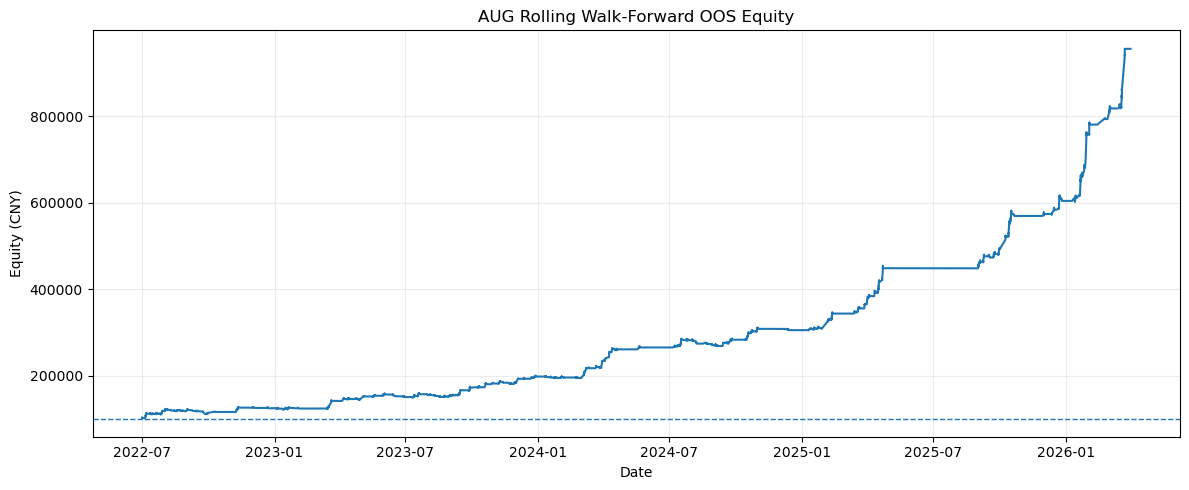

In [25]:
# FINAL OOS EQUITY CURVE

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    oos_results[
        "Timestamp"
    ],
    oos_results[
        "Equity"
    ]
)

plt.axhline(
    INITIAL_EQUITY,
    linestyle="--",
    linewidth=1
)

plt.title(
    "AUG Rolling Walk-Forward OOS Equity"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Equity (CNY)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

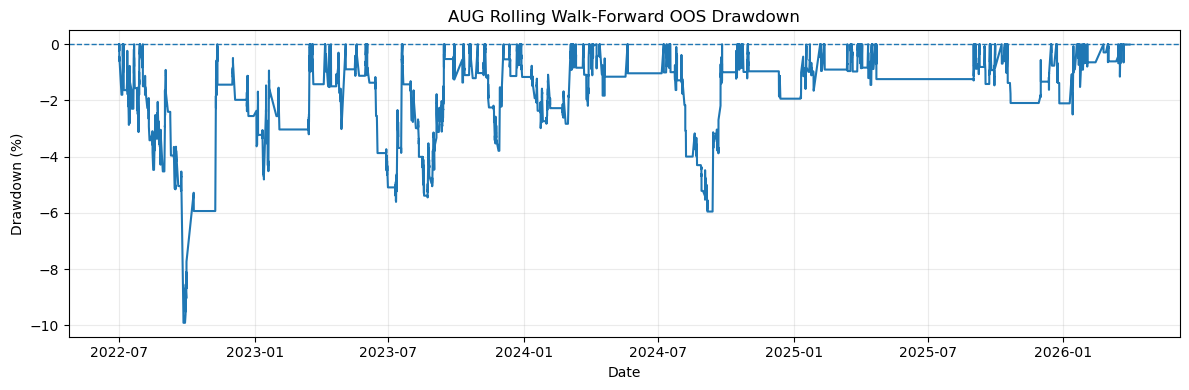

In [26]:
# 11.3 FINAL OOS DRAWDOWN

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    oos_results[
        "Timestamp"
    ],
    drawdown_pct
    *
    100.0
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "AUG Rolling Walk-Forward OOS Drawdown"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Drawdown (%)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

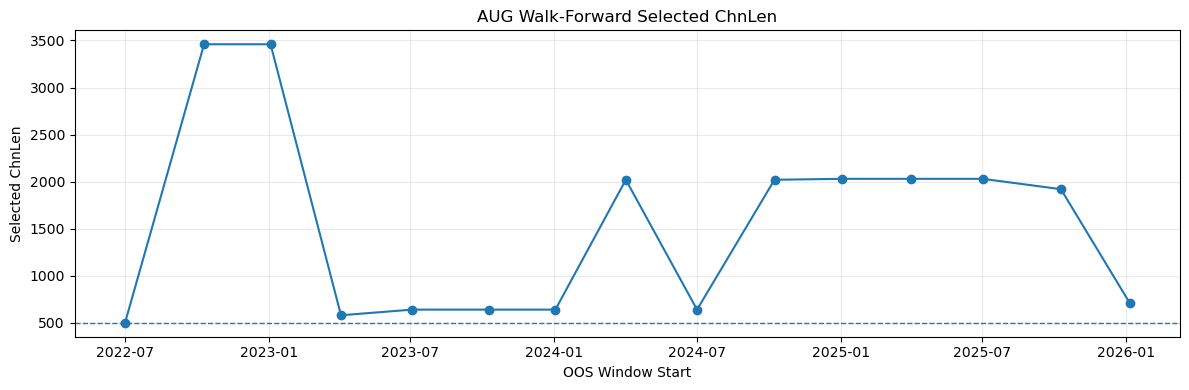

In [27]:
# 11.4 SELECTED CHANNEL LENGTH THROUGH TIME

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    wf_optimization[
        "OOS_Start"
    ],
    wf_optimization[
        "ChnLen"
    ],
    marker="o"
)

plt.axhline(
    CHNLEN_RANGE.min(),
    linestyle="--",
    linewidth=1
)

plt.title(
    "AUG Walk-Forward Selected ChnLen"
)

plt.xlabel(
    "OOS Window Start"
)

plt.ylabel(
    "Selected ChnLen"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

### 11.5 Final Findings

The finalized AUG walk-forward analysis contains 15 complete non-overlapping OOS
quarters from July 2022 through March 2026. The stitched OOS path increases
equity from CNY 100,000 to approximately CNY 955,221, corresponding to an OOS
CAGR of approximately 82.6%, a maximum drawdown of approximately 9.9%, and a
daily Sharpe ratio of approximately 3.61.

All 15 OOS quarters are profitable. At the completed-trade level, 173 trades are
observed, with a win rate of approximately 58.4%, a profit factor of approximately
7.19, and a payoff ratio above 5. Completed trades explain approximately 94.8%
of total portfolio OOS P&L, while boundary-crossing positions account for the
remaining approximately 5.2%.

Trade profitability is not concentrated in only one or two completed trades.
Even after removing the ten largest winning completed trades, the remaining
completed-trade P&L remains strongly positive.

However, the magnitude of the AUG result must be interpreted with caution.
Approximately 76.7% of total OOS P&L is associated with non-contiguous
session-gap bars, principally the 09:05 observations following the previous
15:00 close. Because the dataset does not contain the intraday price path during
these intervals, stop and reversal behavior inside the missing session cannot be
reconstructed exactly. A diagnostic decomposition excluding gap-bar P&L remains
profitable, but it is an attribution analysis rather than an alternative
backtest.

Parameter stability also reveals a boundary effect. Selected channel lengths
vary materially across windows, but StpPct equals the lower grid boundary of
0.005 in all 15 in-sample optimizations. This indicates persistent preference for
a tight trailing stop and should be treated as a parameter-boundary limitation
rather than evidence that 0.005 is the globally optimal economic stop level.

Overall, the AUG results provide strong historical evidence that the strategy can
retain positive OOS performance in a second futures market, but the unusually
high performance level is materially influenced by session-gap exposure and
should not be interpreted as a direct estimate of expected future returns.